# Import all kind of stuff

In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

# $\Delta(r)$

In [165]:
x = np.linspace(0, 3 * 2 * np.pi, 361)
barrier_width = 0.25 * np.pi
barrier_0 = 4 * np.pi
x_barrier0 = barrier_0 - barrier_width / 2
x_barrier1 = barrier_0 + barrier_width / 2

damping = 10 * np.pi
damping1 = np.where(
    x < x_barrier0,
    1.0,
    np.exp((x_barrier0 - x) / damping),
)
damping2 = np.where(
    x > x_barrier1,
    1.0,
    np.exp((-x_barrier1 + x) / damping),
)

nu = 1
phi = 1 * np.pi
phi_0 = np.pi / 2
phi_off = np.pi / 2

psi1 = np.sin((x / (nu) - (phi_0))) ** 1
psi2 = np.sin((x / (nu) - (phi_0 + phi))) ** 1
psi1 *= damping1
psi2 *= damping2

psi_half = 1.1
psi_min = -1
psi_max = 1

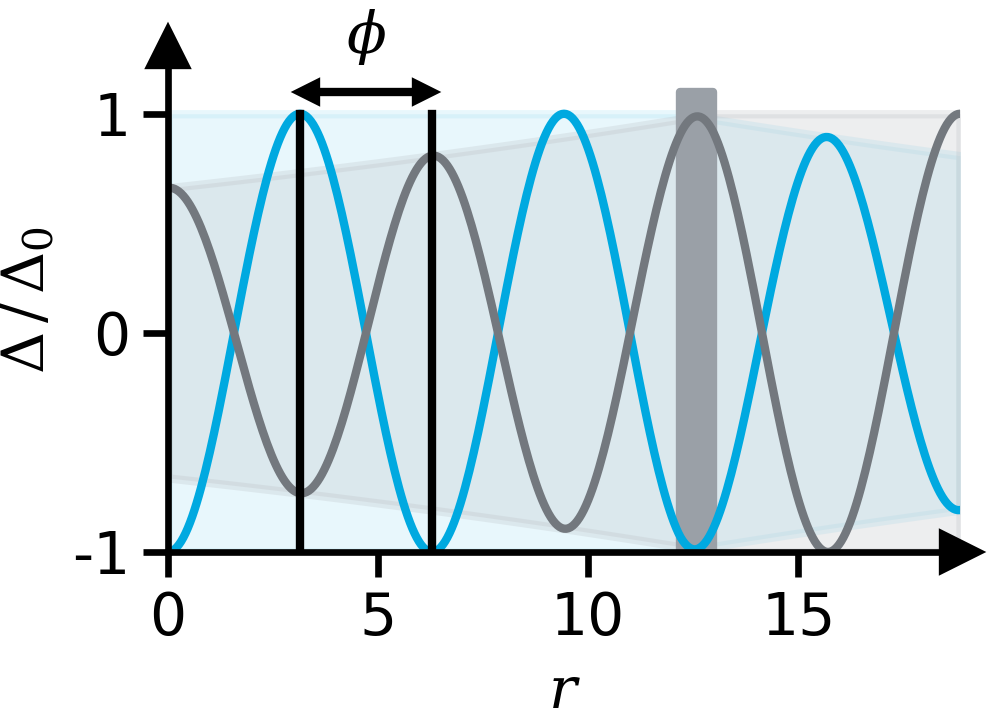

In [166]:
fig, ax = sc.get_figure(figsize=(1.68, 1.2))

# damping
ax.fill_between(
    x, +damping1, -damping1, color=sc.get_color("seeblau", "35", alpha=0.25)
)
ax.fill_between(
    x, +damping2, -damping2, color=sc.get_color("seegrau", "35", alpha=0.25)
)

# barrier
ax.fill_between(
    x=[x_barrier0, x_barrier1],
    y1=[psi_min, psi_min],
    y2=[psi_max * 1.1, psi_max * 1.1],
    color=sc.seegrau65,
    alpha=1,
)

# wave function
ax.plot(x, psi1, color=sc.get_color("seeblau", "100"))
ax.plot(x, psi2, color=sc.get_color("seegrau", "100"))

# ax.plot(x, +damping1, "--", color=get_color("seeblau", "100"))
# ax.plot(x, -damping1, "--", color=get_color("seeblau", "100"))
# ax.plot(x, +damping2, "--", color=get_color("seegrau", "80"))
# ax.plot(x, -damping2, "--", color=get_color("seegrau", "80"))

color = "k"
ax.plot(
    [phi_off + phi_0 + 0.2, phi_off + phi_0 + phi - 0.2],
    [psi_half, psi_half],
    "-",
    color=color,
)
ax.plot([phi_off + phi_0, phi_off + phi_0], [psi_min, psi_max], "-", color=color)
ax.plot(
    [phi_off + phi_0 + phi, phi_off + phi_0 + phi], [psi_min, psi_max], "-", color=color
)
ax.plot(
    [phi_off + phi_0 + phi - 0.2], [psi_half], ">", color=color, clip_on=False, ms=2
)
ax.plot([phi_off + phi_0 + 0.2], [psi_half], "<", color=color, clip_on=False, ms=2)

ax.text(
    phi_off + phi_0 + phi / 2,
    psi_half + 0.25,
    "$\\phi$",
    color="k",
    ha="center",
    va="center",
    fontsize=7,
)

ax.set_ylim(psi_min, psi_max * 1.3)
ax.set_xlim(np.min(x), np.max(x))

# ax.set_xticks([phi_off + phi_0, phi_off + phi_0 + phi], ["$\\phi1$", "$\\phi_2$"])
# ax.set_xticks([phi_off + phi_0 + phi / 2], ["$\\phi$"])
# ax.set_xticks([])
# ax.set_yticks([-1, 0, 1], ["$-|\\Delta|$", "0", "$|\\Delta|$"])
# ax.set_yticks([])

title = "theory/macro/delta-r"
xlabel = "$r$"
ylabel = "$\\Delta\\,/\\,\\Delta_0$"

sc.theory_layout(fig, ax, title, xlabel, ylabel, padding=(0.2, 0.2))

# Josephson $I(\phi)$

In [167]:
phi = np.linspace(0, 2.64 * np.pi, 361)
I_J_phi = np.sin(phi)

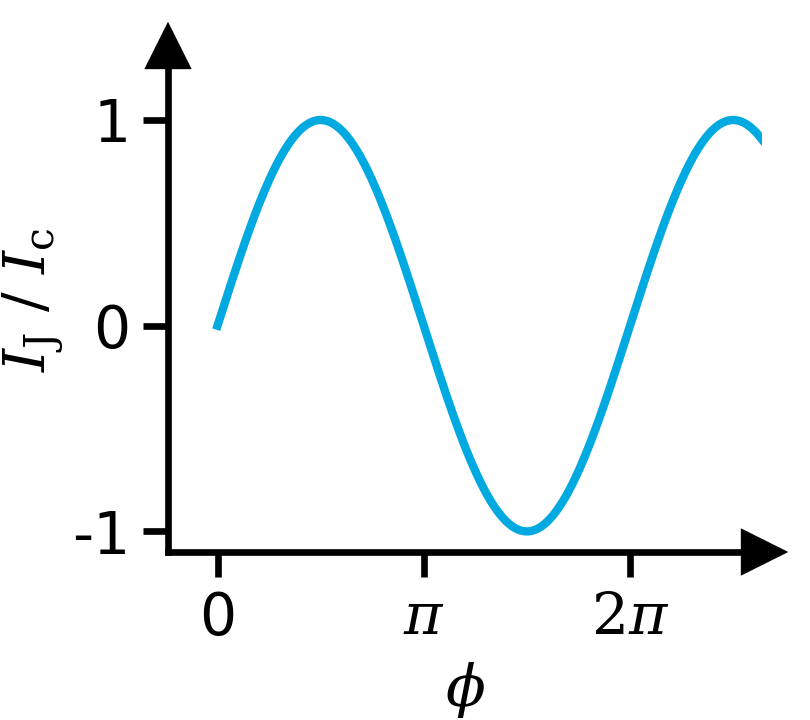

In [168]:
fig, ax = sc.get_figure(figsize=(1.35, 1.2))
ax.plot(
    phi,
    I_J_phi,
    color=sc.seeblau100,
)

ax.set_ylim((-1.1, 1.35))
ax.set_yticks([0, 1, -1])

ax.set_xlim((-0.24 * np.pi, 2.64 * np.pi))
ax.set_xticks([0, np.pi, 2 * np.pi], labels=["0", "$\\pi$", "$2\\pi$"])

xlabel = "$\\phi$"
ylabel = "$I_\\mathrm{J}\\,\\,/\\,\\,I_\\mathrm{c}$"
title = "theory/macro/josephson-iphi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# Josephson $I(t)$

In [169]:
from superconductivity.api import kB_meV_K, G0_muS, h_pVs

Delta_meV = 0.180
t_ps = np.linspace(0, 180, 1001)  # ps
V_mV = np.array([0.03101750772692894])
I_C = np.pi / 2
phi_0 = 0.0

nu_0_GHz = 2 / h_pVs * V_mV
t_0_ps = 1 / nu_0_GHz

phi = np.zeros((t_ps.shape[0], V_mV.shape[0]))
for i, v_mV in enumerate(V_mV):
    phi[:, i] = phi_0 + 2 * np.pi * nu_0_GHz[i] * t_ps * 1e-3

I_J = I_C * np.sin(phi)
t_0_ps, nu_0_GHz

(array([0.06666667]), array([15.]))

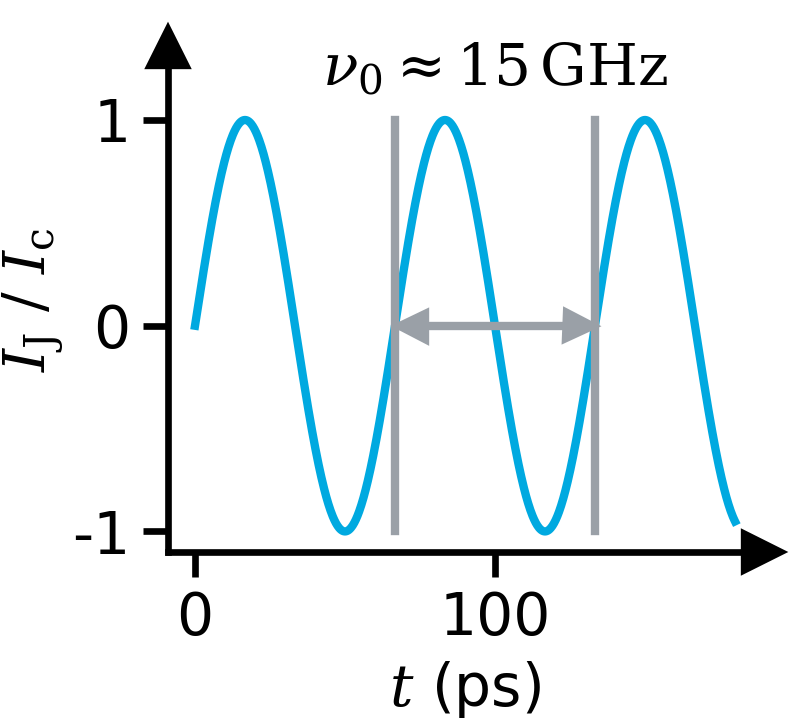

In [170]:
fig, ax = sc.get_figure(figsize=(1.35, 1.2))

for i, v_mV in enumerate(V_mV):
    ax.plot(
        t_ps,
        I_J[:, i] / I_C,
        color=sc.seeblau100,
        zorder=0,
    )
t_0 = 1e3 / nu_0_GHz[0]
ax.plot([t_0 + 0.5, 2 * t_0 - 0.5], [0, 0], "-", color=sc.seegrau65)
ax.plot([t_0, t_0], [-1, 1], "-", color=sc.seegrau65)
ax.plot([2 * t_0, 2 * t_0], [-1, 1], "-", color=sc.seegrau65)
ax.plot([2 * t_0 - 0.5 - 5], [0], ">", color=sc.seegrau65, clip_on=False, ms=3)
ax.plot([t_0 + 0.5 + 5], [0], "<", color=sc.seegrau65, clip_on=False, ms=3)
ax.text(
    t_0 * 1.5,
    1.25,
    "$\\nu_0 \\approx 15\\,\\mathrm{GHz}$",  # t_0 \\approx 11\\,\\mathrm{ps},
    color="k",
    ha="center",
    va="center",
    fontsize=7,
)

ax.set_ylim((-1.1, 1.35))
ax.set_yticks([0, 1, -1])

# ax.set_xlim(-3, 63)
# ax.set_xticks([0, 20, 40])

xlabel = "$t$ (ps)"
ylabel = "$I_\\mathrm{J}\\,\\,/\\,\\,I_\\mathrm{c}$"
title = "theory/macro/josephson-it"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# $I_C(T)$ Ambegaokar-Baratoff

In [171]:
Delta_meV = 0.18
T_c_K = sc.get_Tc_K(Delta_meV=Delta_meV)
T = np.linspace(0, 1, 101)
T_K = T * T_c_K
IcT_AB = sc.get_IcT_ab(T_K=T_K, Delta_meV=Delta_meV, GN_G0=1.0)

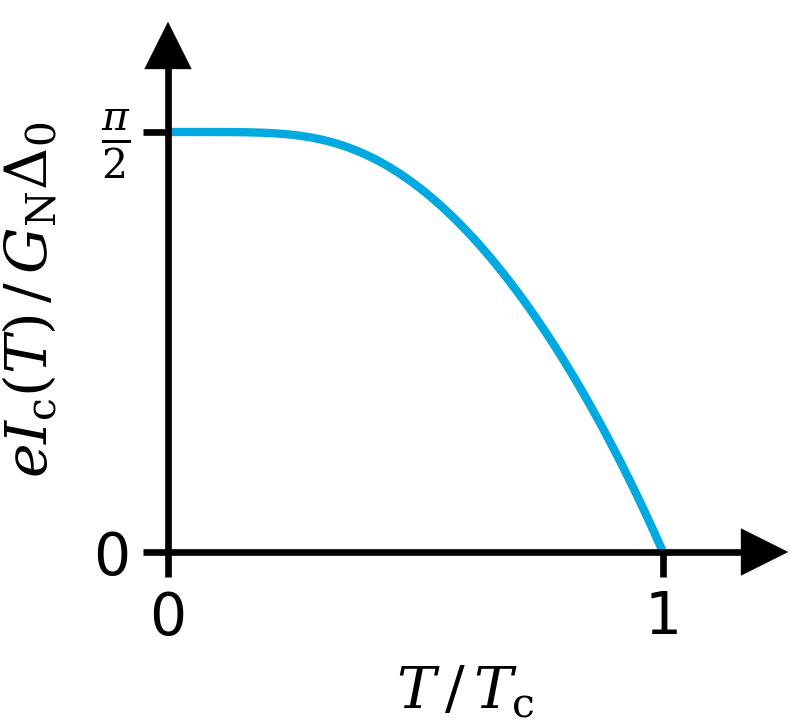

In [172]:
fig, ax = sc.get_figure(figsize=(1.35, 1.2))

# Plot the simplified gap curve
ax.plot(T, IcT_AB, color=sc.seeblau100)

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2 * np.pi / 2)
ax.set_yticks([0, np.pi / 2], labels=["0", "$\\frac{\\pi}{2}$"])
ax.set_xticks([0, 1])

xlabel = "$T\\,/\\,T_\\mathrm{c}$"
ylabel = "$eI_\\mathrm{c}(T)\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/macro/critical-current"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

In [44]:
# Irsj
import matplotlib.pyplot as plt

Delta_meV = 0.18
GN_G0 = 1.0

V = np.linspace(-6, 6, 1201)
V_mV = V * Delta_meV
Ibcs_nA = sc.get_Ibcs_nA(
    V_mV=V_mV,
    GN_G0=GN_G0,
    T_K=0.0,
    Delta_meV=Delta_meV,
    gamma_meV=1e-4,
    kernel="adaptive",
    backend="np",
)
from superconductivity.utilities.functions.upsampling import upsample
from superconductivity.utilities.functions.fill_nans import fill

Ic = np.pi / 2
Ibias_nA = V * Delta_meV * sc.G0_muS * GN_G0
Ic_nA = Ic * Delta_meV * sc.G0_muS * GN_G0

Vbcs_mV = sc.bin_y_over_x(upsample(V_mV), upsample(Ibcs_nA), Ibias_nA)
Vbcs_mV = fill(Vbcs_mV)

from scipy.integrate import quad
from scipy.interpolate import PchipInterpolator


def get_Vrsj_mV(Ibias_nA, Ic_nA, Vbcs_mV):
    """Solve the overdamped Josephson phase equation.

    Parameters
    ----------
    Ibias_nA : array_like
        Bias-current vector in nA. This also defines the current axis of the
        tabulated BCS I-V characteristic.
    Ic_nA : float
        Critical current in nA.
    Vbcs_mV : array_like
        BCS voltage corresponding elementwise to `Ibias_nA`, in mV.

    Returns
    -------
    numpy.ndarray
        Time-averaged junction voltage in mV at every bias current.
    """
    Ibias_nA = np.asarray(Ibias_nA, dtype=float)
    Vbcs_mV = np.asarray(Vbcs_mV, dtype=float)

    if Ibias_nA.ndim != 1 or Vbcs_mV.ndim != 1:
        raise ValueError("Ibias_nA and Vbcs_mV must be one-dimensional.")

    if Ibias_nA.shape != Vbcs_mV.shape:
        raise ValueError("Ibias_nA and Vbcs_mV must have the same length.")

    order = np.argsort(Ibias_nA)
    current_axis = Ibias_nA[order]
    voltage_axis = Vbcs_mV[order]

    if np.any(np.diff(current_axis) <= 0):
        raise ValueError("Ibias_nA must contain unique current values.")

    Vbcs = PchipInterpolator(
        current_axis,
        voltage_axis,
        extrapolate=False,
    )

    Vrsj_mV = np.zeros_like(Ibias_nA)

    for index, bias_nA in enumerate(Ibias_nA):
        # A static phase solution exists in this region.
        if np.abs(bias_nA) <= np.abs(Ic_nA):
            continue

        required_min = bias_nA - np.abs(Ic_nA)
        required_max = bias_nA + np.abs(Ic_nA)

        if required_min < current_axis[0] or required_max > current_axis[-1]:
            Vrsj_mV[index] = np.nan
            continue

        def inverse_phase_velocity(phi):
            quasiparticle_current_nA = bias_nA - Ic_nA * np.sin(phi)
            return 1.0 / Vbcs(quasiparticle_current_nA)

        inverse_voltage_integral, _ = quad(
            inverse_phase_velocity,
            0.0,
            2.0 * np.pi,
            epsabs=1e-10,
            epsrel=1e-8,
            limit=300,
        )

        Vrsj_mV[index] = 2.0 * np.pi / inverse_voltage_integral

    return Vrsj_mV


Vrsj_mV = get_Vrsj_mV(Ibias_nA=Ibias_nA, Ic_nA=Ic_nA, Vbcs_mV=Vbcs_mV)
Ibias = V
Vrsj = Vrsj_mV / Delta_meV
Vbcs = Vbcs_mV / Delta_meV

Vlim = 3.5
Vbcs[np.abs(Vbcs) >= Vlim] = np.nan
Vrsj[np.abs(Vrsj) >= Vlim] = np.nan

/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/bcs/backend/np.py:150: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  value, _ = quad(
/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/bcs/backend/np.py:150: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  value, _ = quad(
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_48179/4063384843.py:90: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  inverse_voltage_integral, _ = quad(


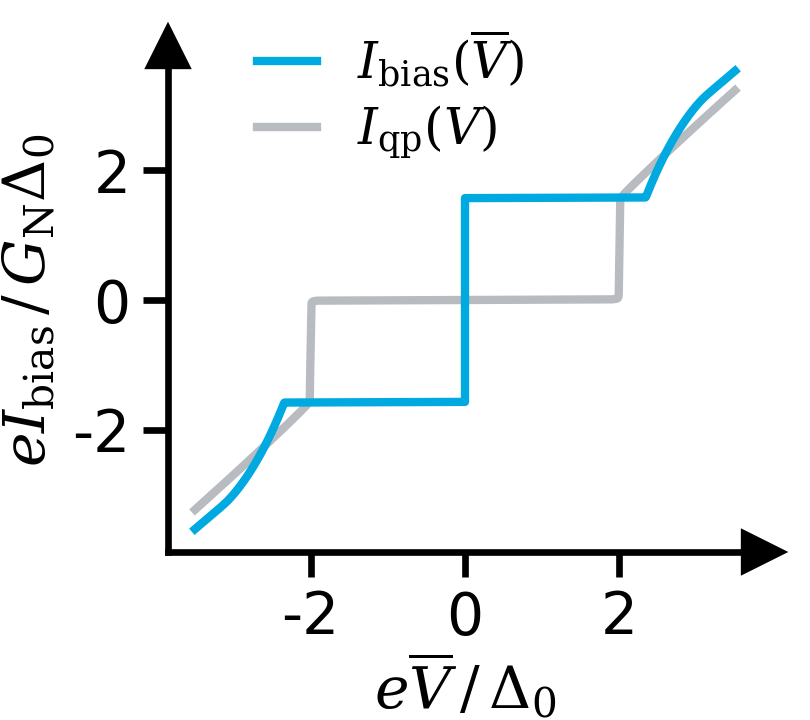

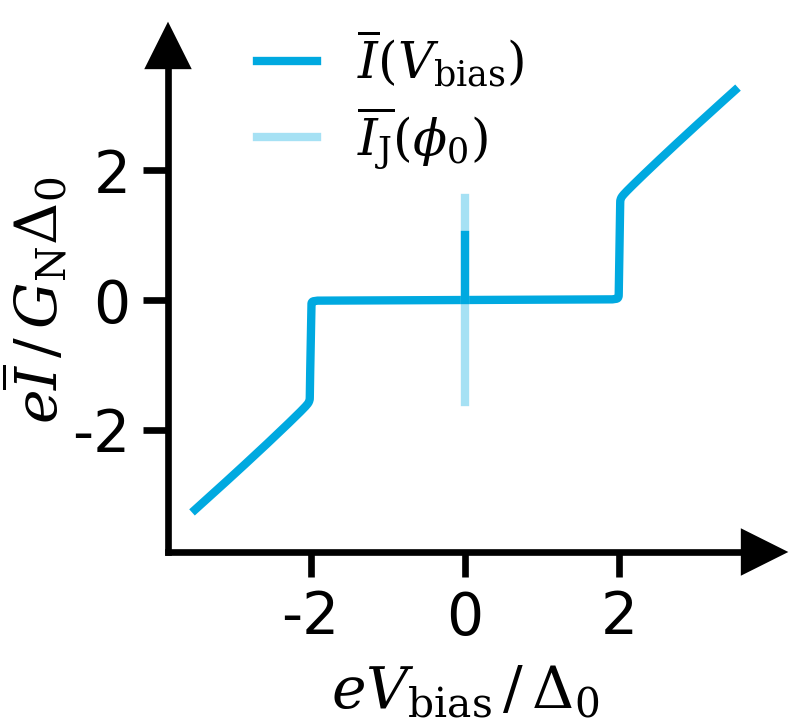

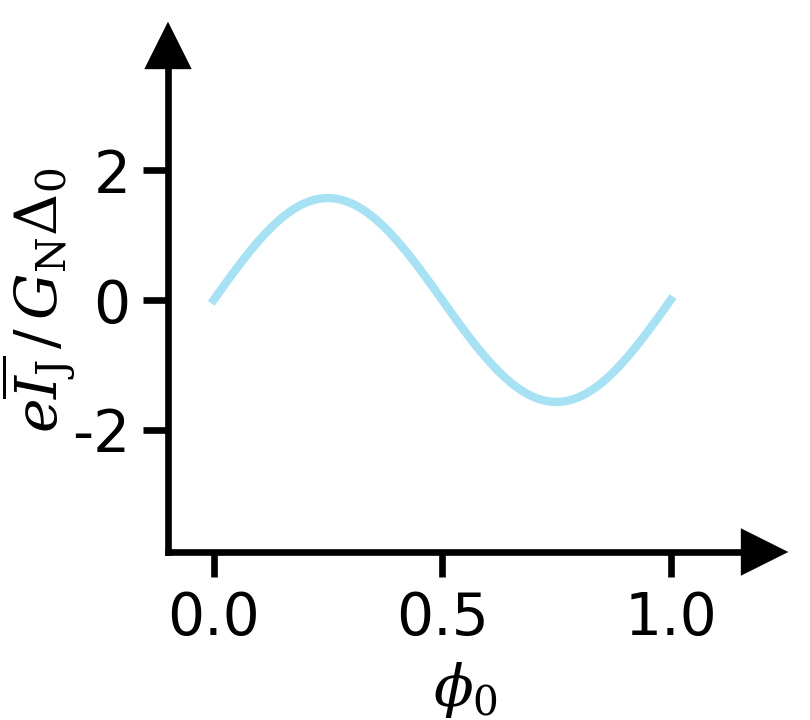

In [45]:
fig, ax = sc.get_figure(figsize=(1.35, 1.2))
ax.plot(
    Vrsj,
    Ibias,
    color=sc.seeblau100,
    label="$I_\\mathrm{bias}(\\overline{V})$",
)
ax.plot(
    Vbcs,
    Ibias,
    color=sc.seegrau35,
    zorder=-1,
    label="$I_\\mathrm{qp}(V)$",
)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

ax.set_xticks([-2, 0, 2])
ax.set_yticks([-2, 0, 2])

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(0.1, 1.1),
)

sc.theory_layout(
    fig,
    ax,
    "theory/macro/Irsj",
    "$e\\overline{V}\,/\,\\Delta_0$",
    "$eI_\\mathrm{bias}\\,/\\,G_\\mathrm{N}\\Delta_0$",
)

fig, ax = sc.get_figure(figsize=(1.35, 1.2))
ax.plot(
    Vbcs,
    Ibias,
    color=sc.seeblau100,
    zorder=1,
    label="$\\overline{I}(V_\\mathrm{bias})$",
)
ax.plot(
    [0, 0],
    [-Ic, Ic],
    color=sc.seeblau35,
    label="$\\overline{I_\\mathrm{J}}(\\phi_0)$",
)
ax.plot(
    [0, 0],
    [0, 1],
    color=sc.seeblau100,
)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(0.1, 1.1),
)

ax.set_xticks([-2, 0, 2])
ax.set_yticks([-2, 0, 2])

ax.set_xlim(xlim)
ax.set_ylim(ylim)

sc.theory_layout(
    fig,
    ax,
    "theory/macro/Ibcs",
    "$eV_\\mathrm{bias}\,/\,\\Delta_0$",
    "$e\\overline{I}\\,/\\,G_\\mathrm{N}\\Delta_0$",
)

fig, ax = sc.get_figure(figsize=(1.35, 1.2))
phi0 = np.linspace(0, 1.0, 101)
IJ = np.sin(phi0 * 2 * np.pi) * np.pi / 2
ax.plot(phi0, IJ, color=sc.seeblau35)

ax.set_xlim([-0.1, 1.2])
ax.set_yticks([-2, 0, 2])

# ax.set_xlim(xlim)
ax.set_ylim(ylim)

sc.theory_layout(
    fig,
    ax,
    "theory/macro/Ic",
    "$\\phi_0$",
    "$e\\overline{I_\\mathrm{J}}\\,/\\,G_\\mathrm{N}\\Delta_0$",
)

# $U(\phi)$

In [366]:
I = np.array([0, 0.5, 0.99])
phi = np.linspace(-2.6, 0.6, 321)
phi_pi = phi * 2 * np.pi
U_phi = np.zeros((phi.shape[0], I.shape[0]))
for j, i in enumerate(I):

    U_phi[:, j] = -np.cos(phi_pi) - i * phi_pi

dudphi = np.abs(np.gradient(U_phi, phi, axis=0))


def local_minima_indices(y: np.ndarray, *, strict: bool = True) -> np.ndarray:
    y = np.asarray(y)
    if y.ndim != 1 or y.size < 3:
        return np.zeros(0, dtype=int)

    if strict:
        m = (y[1:-1] < y[:-2]) & (y[1:-1] < y[2:])
    else:
        m = (
            (y[1:-1] <= y[:-2])
            & (y[1:-1] <= y[2:])
            & ((y[1:-1] < y[:-2]) | (y[1:-1] < y[2:]))
        )
    return np.flatnonzero(m) + 1


idx0 = local_minima_indices(+dudphi[:, 0])
idx1 = local_minima_indices(+dudphi[:, 1])
idx2 = local_minima_indices(-dudphi[:, 2])

x_ball0 = phi[idx0[1]]
x_ball1a = phi[idx1[1]]
x_ball1b = phi[idx1[3]]
x_ball2 = phi[idx2[2]]

U_phi_0_move = np.copy(U_phi[:, 0])
U_phi_1a_move = np.copy(U_phi[:, 1])
U_phi_1b_move = np.copy(U_phi[:, 1])
U_phi_2_move = np.copy(U_phi[:, 2])

U_phi_0_move += 0.8
U_phi_1a_move += 0.8
U_phi_1b_move += 0.8
U_phi_2_move += 0.8

y_ball0 = U_phi_0_move[idx0[1]]
y_ball1a = U_phi_1a_move[idx1[1]]
y_ball1b = U_phi_1b_move[idx1[3]]
y_ball2 = U_phi_2_move[idx2[2]]

U_phi_0_move[U_phi_0_move >= y_ball0 + 0.3] = np.nan
U_phi_0_move[phi >= -1.5] = np.nan

U_phi_1a_move[U_phi_1a_move >= y_ball1a + 0.3] = np.nan
U_phi_1a_move[U_phi_1a_move < y_ball1a] = np.nan
U_phi_1a_move[phi >= -1.5] = np.nan

U_phi_1b_move[U_phi_1b_move >= y_ball1b + 0.3] = np.nan
U_phi_1b_move[U_phi_1b_move < y_ball1b] = np.nan
U_phi_1b_move[phi >= -0.6] = np.nan

U_phi_2_move[U_phi_2_move <= 0.05] = np.nan
# U_phi_1_move[phi <= -1.2] = np.nan

U_phi_jump = np.copy(U_phi[:, 1])
U_phi_jump += 1.6
U_phi_jump[phi < -1.6] = np.nan
U_phi_jump[phi > -1.2] = np.nan

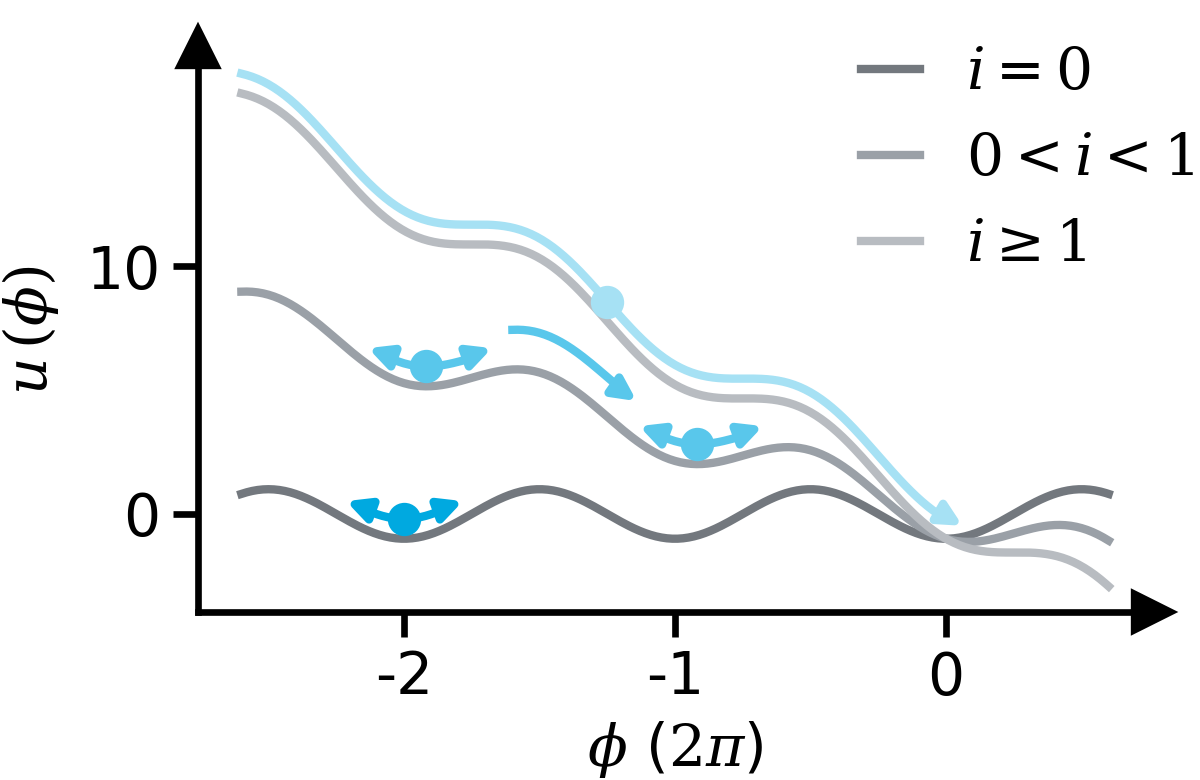

In [367]:
fig, ax = sc.get_figure(
    figsize=(2.0, 1.3),
    subfigure=True,
    padding=(0.25, 0.2),
)

jump_color = sc.seeblau65

# trajectories
ax.plot(phi, U_phi_0_move, color=sc.seeblau100)
ax.plot(phi, U_phi_1a_move, color=sc.seeblau65)
ax.plot(phi, U_phi_2_move, color=sc.seeblau35)

# phase slips
ax.plot(phi, U_phi_1b_move, color=sc.seeblau65)
ax.plot(phi, U_phi_jump, color=jump_color)

s = 5

# marker phase slip
ms = MarkerStyle(">")
ms._transform = ms.get_transform().rotate_deg(-35)
ax.scatter([-1.2], [5], marker=ms, s=s, color=jump_color, clip_on=False)

# marker stable phase
ms = MarkerStyle(">")
ms._transform = ms.get_transform().rotate_deg(20)
ax.scatter(
    [x_ball0 + 0.15],
    [y_ball0 + 0.5],
    marker=ms,
    s=s,
    color=sc.seeblau100,
    clip_on=False,
)

ms = MarkerStyle("<")
ms._transform = ms.get_transform().rotate_deg(-20)
ax.scatter(
    [x_ball0 - 0.15],
    [y_ball0 + 0.5],
    marker=ms,
    s=s,
    color=sc.seeblau100,
    clip_on=False,
)

# marker meat-stable phase
ms = MarkerStyle(">")
ms._transform = ms.get_transform().rotate_deg(20)
ax.scatter(
    [x_ball1a + 0.18],
    [y_ball1a + 0.5],
    marker=ms,
    s=s,
    color=sc.seeblau65,
    clip_on=False,
)

ms = MarkerStyle("<")
ms._transform = ms.get_transform().rotate_deg(-20)
ax.scatter(
    [x_ball1a - 0.15],
    [y_ball1a + 0.5],
    marker=ms,
    s=s,
    color=sc.seeblau65,
    clip_on=False,
)

ms = MarkerStyle(">")
ms._transform = ms.get_transform().rotate_deg(20)
ax.scatter(
    [x_ball1b + 0.18],
    [y_ball1b + 0.5],
    marker=ms,
    s=s,
    color=sc.seeblau65,
    clip_on=False,
)

ms = MarkerStyle("<")
ms._transform = ms.get_transform().rotate_deg(-20)
ax.scatter(
    [x_ball1b - 0.15],
    [y_ball1b + 0.5],
    marker=ms,
    s=s,
    color=sc.seeblau65,
    clip_on=False,
)

# marker running phase
ms = MarkerStyle(">")
ms._transform = ms.get_transform().rotate_deg(-30)
ax.scatter([0], [-0.1], marker=ms, s=s, color=sc.seeblau35, clip_on=False)

# phase particles
ms = 3
ax.plot(x_ball0, y_ball0, "o", color=sc.seeblau100, clip_on=False, ms=ms)
ax.plot(x_ball1a, y_ball1a, "o", color=sc.seeblau65, clip_on=False, ms=ms)
ax.plot(x_ball1b, y_ball1b, "o", color=sc.seeblau65, clip_on=False, ms=ms)
ax.plot(x_ball2, y_ball2, "o", color=sc.seeblau35, clip_on=False, ms=ms)

seegraus = [sc.seegrau100, sc.seegrau65, sc.seegrau35]
handles = ["$i=0$", "$0 < i < 1$", "$i\\geq 1$"]
for j, i in enumerate(I):
    ax.plot(phi, U_phi[:, j], color=seegraus[j], zorder=0, label=handles[j])

ax.set_xticks([-2, -1, 0])
# ax.set_yticks([])
ax.legend(
    # ,
    # ["$i=0$", "$i \\in [0, 1]$", "$i\\geq 1$"],
    # title="$i=$",
    handlelength=1.0,
    loc="upper right",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=1.0,
    bbox_to_anchor=(1.1, 1.1),
)

title = "theory/macro/u-phi"
xlabel = "$\\phi$ ($2\\pi$)"
ylabel = "$u\\, (\\phi)$"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# RSCJ - $I(V)$

In [192]:
Delta_meV = 0.18
gamma_meV = 1e-4
T_K = 0.0
GN_G0 = 1.0
I_C = np.pi / 2
I_sw = 1
I_r = 0.5
V = np.linspace(0, 2.5, 601)
V_mV = V * Delta_meV  # mV

from superconductivity.models.bcs import get_Ibcs_nA as get_I_bcs_nA

I_BCS = get_I_bcs_nA(
    V_mV=V_mV,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
    T_K=T_K,
    gamma_meV=gamma_meV,
    backend="np",
    kernel="adaptive",
) / (Delta_meV * G0_muS)

I_JJ = V_mV / Delta_meV * 15
I_PD = V_mV / Delta_meV * 0.03

I_SW = np.copy(I_JJ)
I_SW[I_SW > I_sw] = I_sw
I_SW[I_BCS > I_SW] = I_BCS[I_BCS > I_SW]

I_R = np.copy(I_JJ)
I_R[I_R > I_r] = I_r
I_R[I_BCS > I_R] = I_BCS[I_BCS > I_R]

I_SW_sc = np.copy(I_SW)
I_SW_sc[I_SW_sc >= I_sw] = np.nan
I_SW_jp = np.copy(I_SW)
I_SW_jp[I_SW_jp != I_sw] = np.nan
I_SW_dp = np.copy(I_SW)
I_SW_dp[I_SW_dp <= I_sw] = np.nan

I_R_sc = np.copy(I_R)
I_R_sc[I_R_sc >= I_r] = np.nan
I_R_jp = np.copy(I_R)
I_R_jp[I_R_jp != I_r] = np.nan
I_R_dp = np.copy(I_R)
I_R_dp[I_R_dp <= I_r] = np.nan

/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/bcs/backend/np.py:150: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  value, _ = quad(


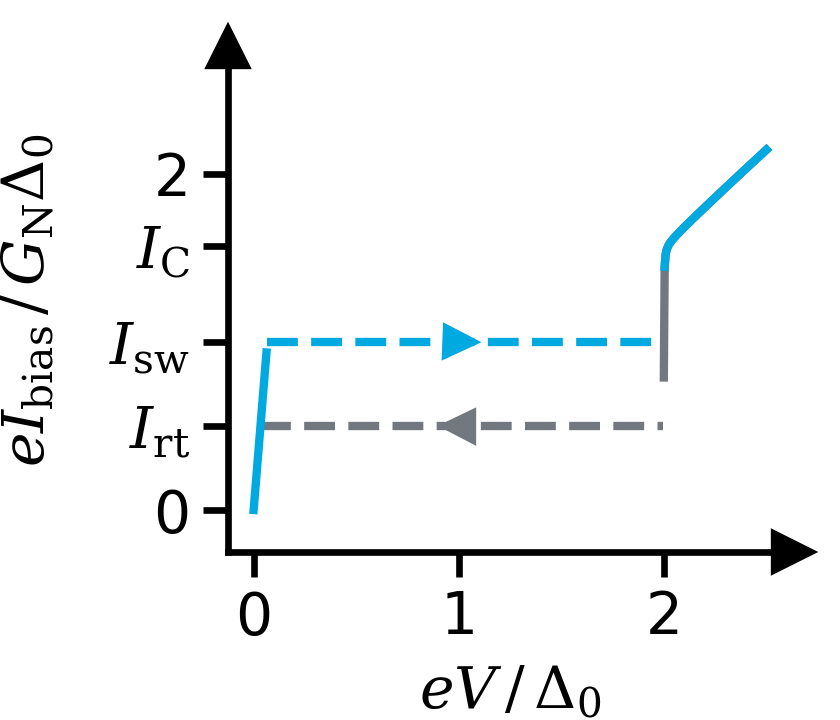

In [194]:
fig, ax = sc.get_figure(figsize=(1.4, 1.2), padding=(0.3, 0.2))

ax.plot(V, I_R_jp, "--", color=sc.seegrau100)
ax.plot(V, I_R_dp, color=sc.seegrau100)
ax.plot(1, I_r, "<", color=sc.seegrau100, clip_on=False, ms=3)

ax.plot(V, I_SW_sc, color=sc.seeblau100)
ax.plot(V, I_SW_jp, "--", color=sc.seeblau100)
ax.plot(V, I_SW_dp, color=sc.seeblau100)
ax.plot(1, I_sw, ">", color=sc.seeblau100, clip_on=False, ms=3)

# ax.plot(V, I_R_sc, color=seegrau100)

# ax.set_xlim((-0.3, 3))
ax.set_xticks([0, 1, 2], labels=["0", "1", "2"])

ax.set_ylim(-0.25, 2.75)
ax.set_yticks(
    [0, 2, I_C, I_sw, I_r],
    labels=["0", "2", "$I_\\mathrm{C}$", "$I_\\mathrm{sw}$", "$I_\\mathrm{rt}$"],
)


xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI_\\mathrm{bias}\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/macro/rcsj-iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# Shapiro iv (over, under, ideal)
https://www.researchgate.net/figure/Schematic-current-voltage-characteristics-of-underdamped-left-and-overdamped-right_fig1_235889223

In [117]:
# generate data

from scipy.special import jv

Delta_meV = 0.180
V_mV = np.linspace(-3, 3, 601) * Delta_meV  # mV
A_mV = np.array([0, 0.3, 0.6]) * Delta_meV  # mV
n = np.arange(-10, 11, 1)
I_bias = np.linspace(-3, 3, 601)

GN_G0 = 1
T_K = 0.0
gamma_meV = 0.0
nu_GHz = 15.0
m = 2

nu_mV = nu_GHz * sc.h_pVs
alpha = m * A_mV / nu_mV
V_n_mV = n / m * nu_mV
V_n = V_n_mV / Delta_meV

I_C = np.pi / 2
I_SW_over = 0.5
I_SW_under = 0.5

from superconductivity.models.bcs import get_Ibcs_nA as get_I_bcs_nA

I_PAT = get_I_bcs_nA(
    A_mV=A_mV,
    V_mV=V_mV,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
    T_K=0.0,
    sigmaV_mV=0.0,
    nu_GHz=nu_GHz,
    gamma_meV=1e-7,
    backend="np",
    kernel="adaptive",
)
I_PAT /= Delta_meV * G0_muS

# PAT (Current Bias)
V_PAT = np.empty((I_bias.shape[0], A_mV.shape[0]), dtype=np.float64)
for i, a_mV in enumerate(A_mV):
    V_over, I_over = sc.upsample(V_mV / Delta_meV, I_PAT[i, :], factor=100)
    V_PAT[:, i] = sc.bin_y_over_x(V_over, I_over, I_bias)

# Shapiro Heights
w = np.empty((A_mV.shape[0], n.shape[0]))
for i_a, a_mV in enumerate(A_mV):
    for i_n, n_i in enumerate(n):
        w_i = np.abs(jv(int(n_i), float(alpha[i_a])))
        w[i_a, i_n] = w_i

# zorder
idx = np.empty_like(w)
for i_n, n_i in enumerate(n):
    idx_i = np.argsort(w[:, i_n])
    idx[:, i_n] = idx_i

# overdamped Shapiro
V_over = np.copy(V_PAT)
for i_a, a_mV in enumerate(A_mV):
    for i_n, n_i in enumerate(n):
        w_i = w[i_a, i_n]
        w_lower = np.sum(w[i_a, 10:i_n])
        w_upper = np.sum(w[i_a, 10 : (i_n + 1)])
        if w_upper < I_C:
            if w_lower > -I_C:
                v = V_over[:, i_a]
                v = np.where(
                    np.logical_and(
                        I_bias <= w_upper * I_SW_over,
                        I_bias >= w_lower * I_SW_over,
                    ),
                    V_n[i_n],
                    v,
                )
                v = np.where(
                    np.logical_and(
                        I_bias >= -w_upper * I_SW_over,
                        I_bias <= -w_lower * I_SW_over,
                    ),
                    -V_n[i_n],
                    v,
                )
                V_over[:, i_a] = v

/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/bcs/backend/np.py:150: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  value, _ = quad(


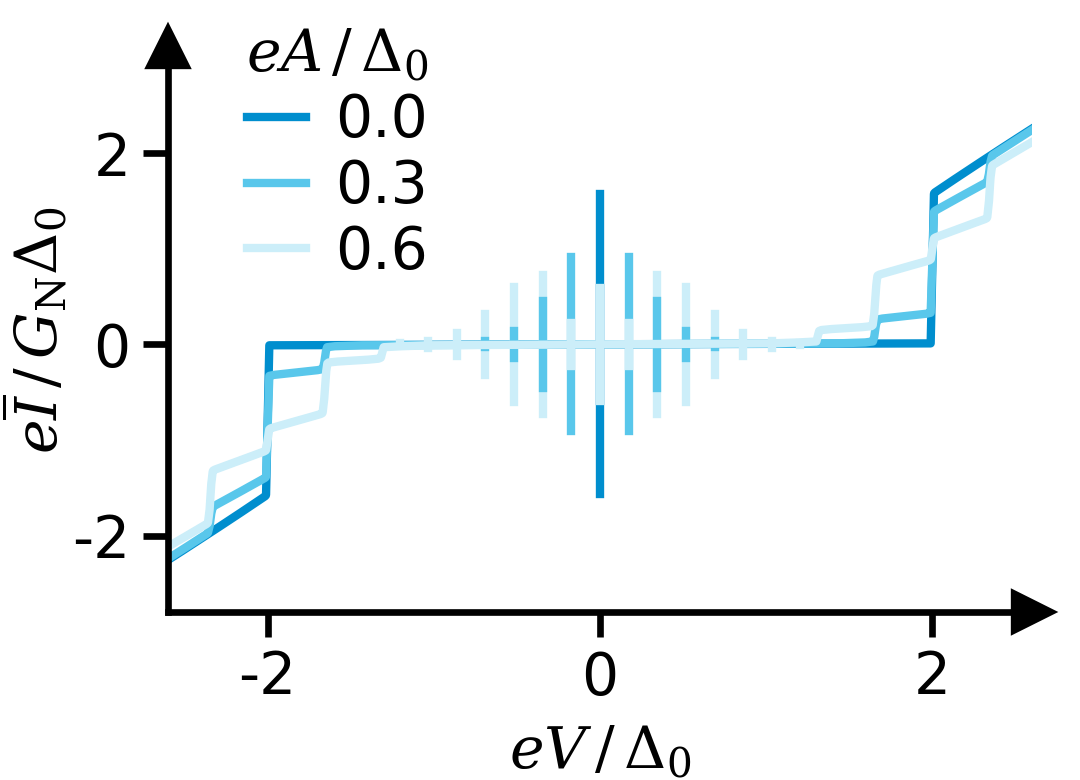

In [118]:
fig, ax = sc.get_figure(figsize=(1.8, 1.3))

colors = [sc.seeblau100, sc.seeblau65, sc.seeblau35]

for i_a, a_mV in enumerate(A_mV):
    ax.plot(
        V_PAT[:, i_a],
        I_bias,
        "-",
        color=sc.seeblau[2 * i_a],
        ms=1,
        zorder=i_a,
    )
    for i_n, n_i in enumerate(n):
        V_ss = V_n[i_n]
        I_ss = w[i_a, i_n] * I_C
        if I_ss >= 0.01:
            ax.plot(
                [V_ss, V_ss],
                [-I_ss, I_ss],
                "-",
                color=sc.seeblau[2 * i_a],
                zorder=3 - idx[i_a, i_n],
            )


handles, labels = [], []
for i, a_mV in enumerate(A_mV):
    line_handle = Line2D([0], [0], color=sc.seeblau[2 * i], linestyle="-")
    label = f"{A_mV[i]/Delta_meV:1.1f}"
    handles.append(line_handle)
    labels.append(label)
ax.legend(
    handles=handles,
    labels=labels,
    title="$eA\\,/\\,\\Delta_0$",
    handlelength=1.0,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    # bbox_to_anchor=(0.5, 1.15),
    bbox_to_anchor=(0.05, 1.1),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.8, 3.1)

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$e\\overline{I}\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/macro/shapiro-ideal"

sc.theory_layout(fig, ax, title, xlabel, ylabel, padding=(0.3, 0.3))

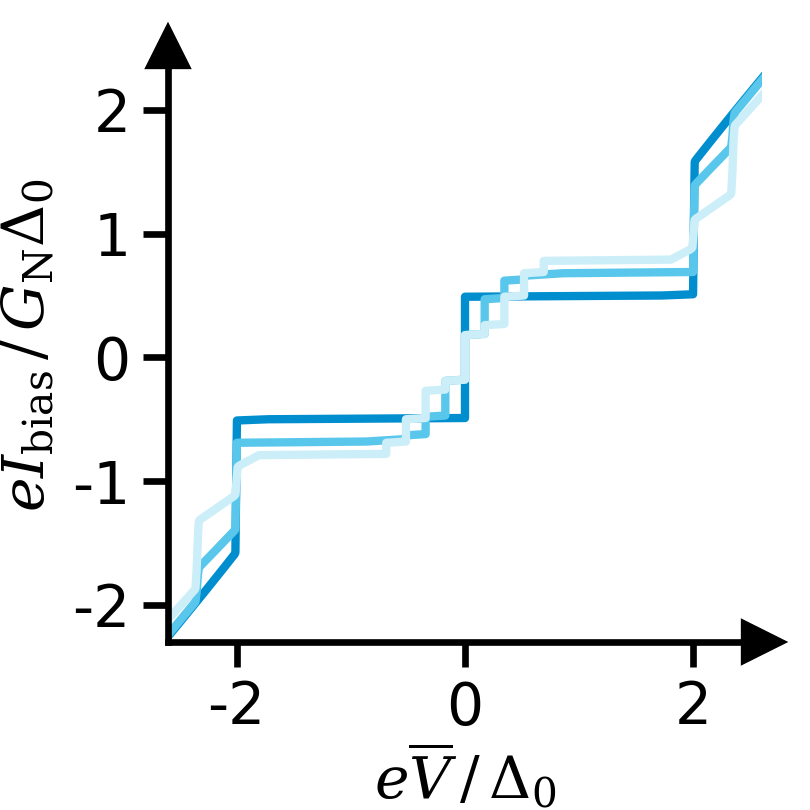

In [119]:
fig, ax = sc.get_figure(figsize=(1.35, 1.35))

for i, a_mV in enumerate(A_mV):
    ax.plot(
        V_over[:, i],
        I_bias,
        "-",
        color=sc.seeblau[2 * i % 5],
    )


handles, labels = [], []
for i, a_mV in enumerate(A_mV):
    line_handle = Line2D([0], [0], color=sc.seeblau[2 * i % 5], linestyle="-")
    label = f"{A_mV[i]/Delta_meV:1.1f}"
    handles.append(line_handle)
    labels.append(label)
# ax.legend(
#     handles=handles,
#     labels=labels,
#     title="$eA/\\Delta_0$",
#     handlelength=1.0,
#     loc="upper left",
#     frameon=False,
#     fontsize=6,
#     title_fontsize=6,
#     # bbox_to_anchor=(0.4, 1.15),
#     bbox_to_anchor=(0.1, 1.1),
#     borderpad=0.1,  # reduces padding inside the legend box
#     labelspacing=0.15,  # reduces vertical spacing between items
#     handletextpad=0.5,  # reduces spacing between line and label
# )


ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.3, 2.5)

xlabel = "$e\\overline{V}\\,/\\,\\Delta_0$"
ylabel = "$eI_\\mathrm{bias}\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/macro/shapiro-over"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

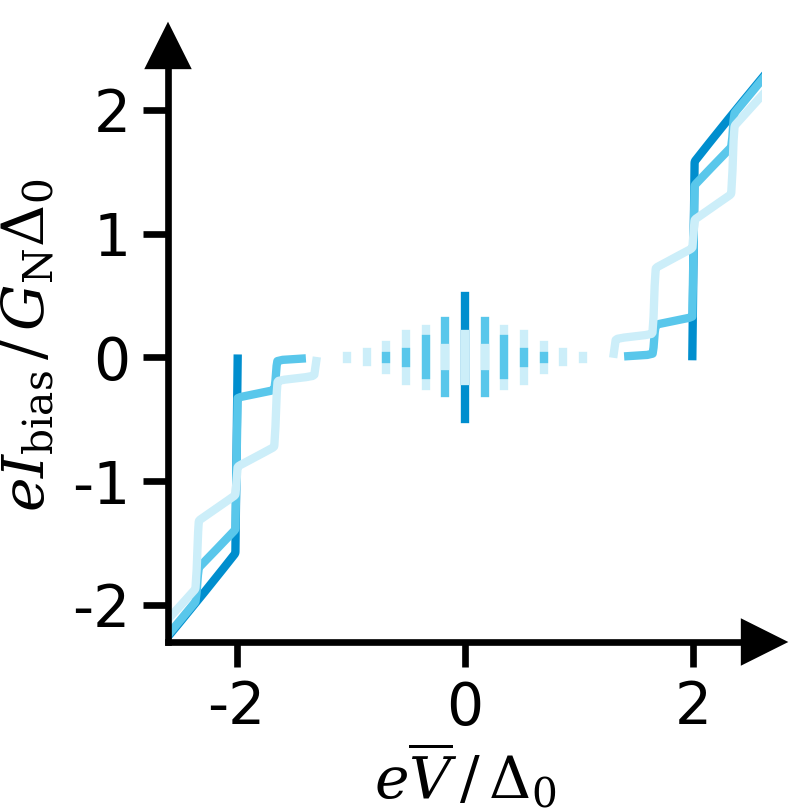

In [120]:
fig, ax = sc.get_figure(figsize=(1.35, 1.35))

for i_a, a_mV in enumerate(A_mV):
    x = np.copy(V_PAT[:, i_a])
    y = np.copy(I_bias)
    y[np.abs(x) <= 1.2] = np.nan
    ax.plot(x, y, "-", color=sc.seeblau[2 * i_a], zorder=i_a, ms=1)
    for i_n, n_i in enumerate(n):
        V_ss = V_n[i_n]
        I_ss = w[i_a, i_n] * I_SW_under
        if I_ss >= 0.01:
            ax.plot(
                [V_ss, V_ss],
                [-I_ss, I_ss],
                "-",
                color=sc.seeblau[2 * i_a],
                zorder=3 - idx[i_a, i_n],
            )


handles, labels = [], []
for i, a_mV in enumerate(A_mV):
    line_handle = Line2D([0], [0], color=sc.seeblau[2 * i], linestyle="-")
    label = f"{A_mV[i]/Delta_meV:1.1f}"
    handles.append(line_handle)
    labels.append(label)
# ax.legend(
#     handles=handles,
#     labels=labels,
#     title="$eA/\\Delta_0$",
#     handlelength=1.0,
#     loc="upper left",
#     frameon=False,
#     fontsize=6,
#     title_fontsize=6,
#     # bbox_to_anchor=(0.4, 1.15),
#     bbox_to_anchor=(0.1, 1.1),
#     borderpad=0.1,  # reduces padding inside the legend box
#     labelspacing=0.15,  # reduces vertical spacing between items
#     handletextpad=0.5,  # reduces spacing between line and label
# )

ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.3, 2.5)

xlabel = "$e\\overline{V}\\,/\\,\\Delta_0$"
ylabel = "$eI_\\mathrm{bias}\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/macro/shapiro-under"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

In [121]:
# Shapiro in RSJ(R)
from rsj import sim_V_rsj_mV
from superconductivity.utilities.functions.upsampling import upsample

Ibias = np.linspace(-3, 3, 601)
Abias = np.linspace(0, 3, 301)
Abias = np.array([0, 0.3, 0.6])
Ic = np.pi / 2
nu_GHz = 15.0

Delta_meV = 0.18
Ic_nA = Ic * Delta_meV * sc.G0_muS
Ibias_nA = Ibias * Delta_meV * sc.G0_muS
Abias_nA = Abias * Ic_nA
R_kOhm = 1e3 / sc.G0_muS
Vrsj_mV = sim_V_rsj_mV(
    I_dc_nA=Ibias_nA,
    I_ac_nA=Abias_nA,
    I_c_nA=Ic_nA,
    R_kOhm=R_kOhm,
    nu_GHz=nu_GHz,
)
Vrsj = Vrsj_mV / Delta_meV
Irsj = sc.bin_y_over_x(upsample(Ibias), upsample(Vrsj), Ibias)

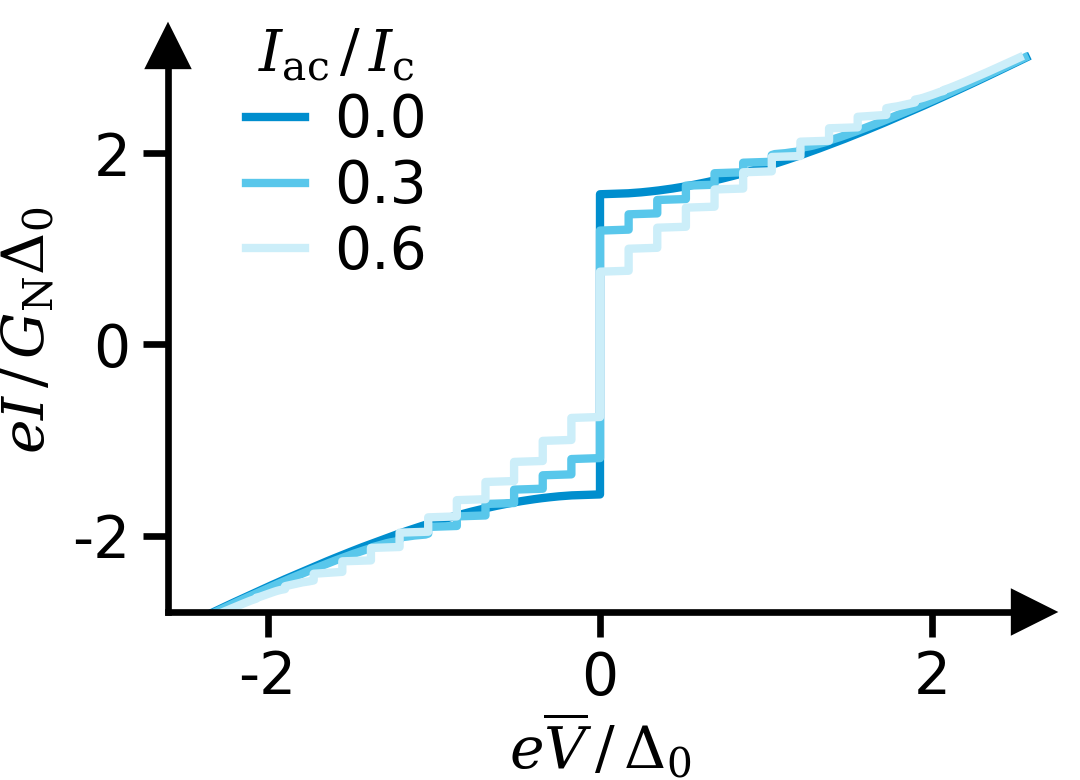

In [122]:
fig, ax = sc.get_figure(figsize=(1.8, 1.3))

colors = [sc.seeblau100, sc.seeblau65, sc.seeblau35]

for i_a, a_mV in enumerate(Abias):
    ax.plot(
        Vrsj[i_a, :],
        Ibias,
        "-",
        color=sc.seeblau[2 * i_a],
        ms=1,
        zorder=i_a,
    )


handles, labels = [], []
for i, a_mV in enumerate(A_mV):
    line_handle = Line2D([0], [0], color=sc.seeblau[2 * i], linestyle="-")
    label = f"{A_mV[i]/Delta_meV:1.1f}"
    handles.append(line_handle)
    labels.append(label)
ax.legend(
    handles=handles,
    labels=labels,
    title="$I_\\mathrm{ac}\\,/\\,I_\\mathrm{c}$",
    handlelength=1.0,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    # bbox_to_anchor=(0.5, 1.15),
    bbox_to_anchor=(0.05, 1.1),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.8, 3.1)

xlabel = "$e\\overline{V}\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/macro/shapiro-rsj"

sc.theory_layout(fig, ax, title, xlabel, ylabel, padding=(0.3, 0.3))

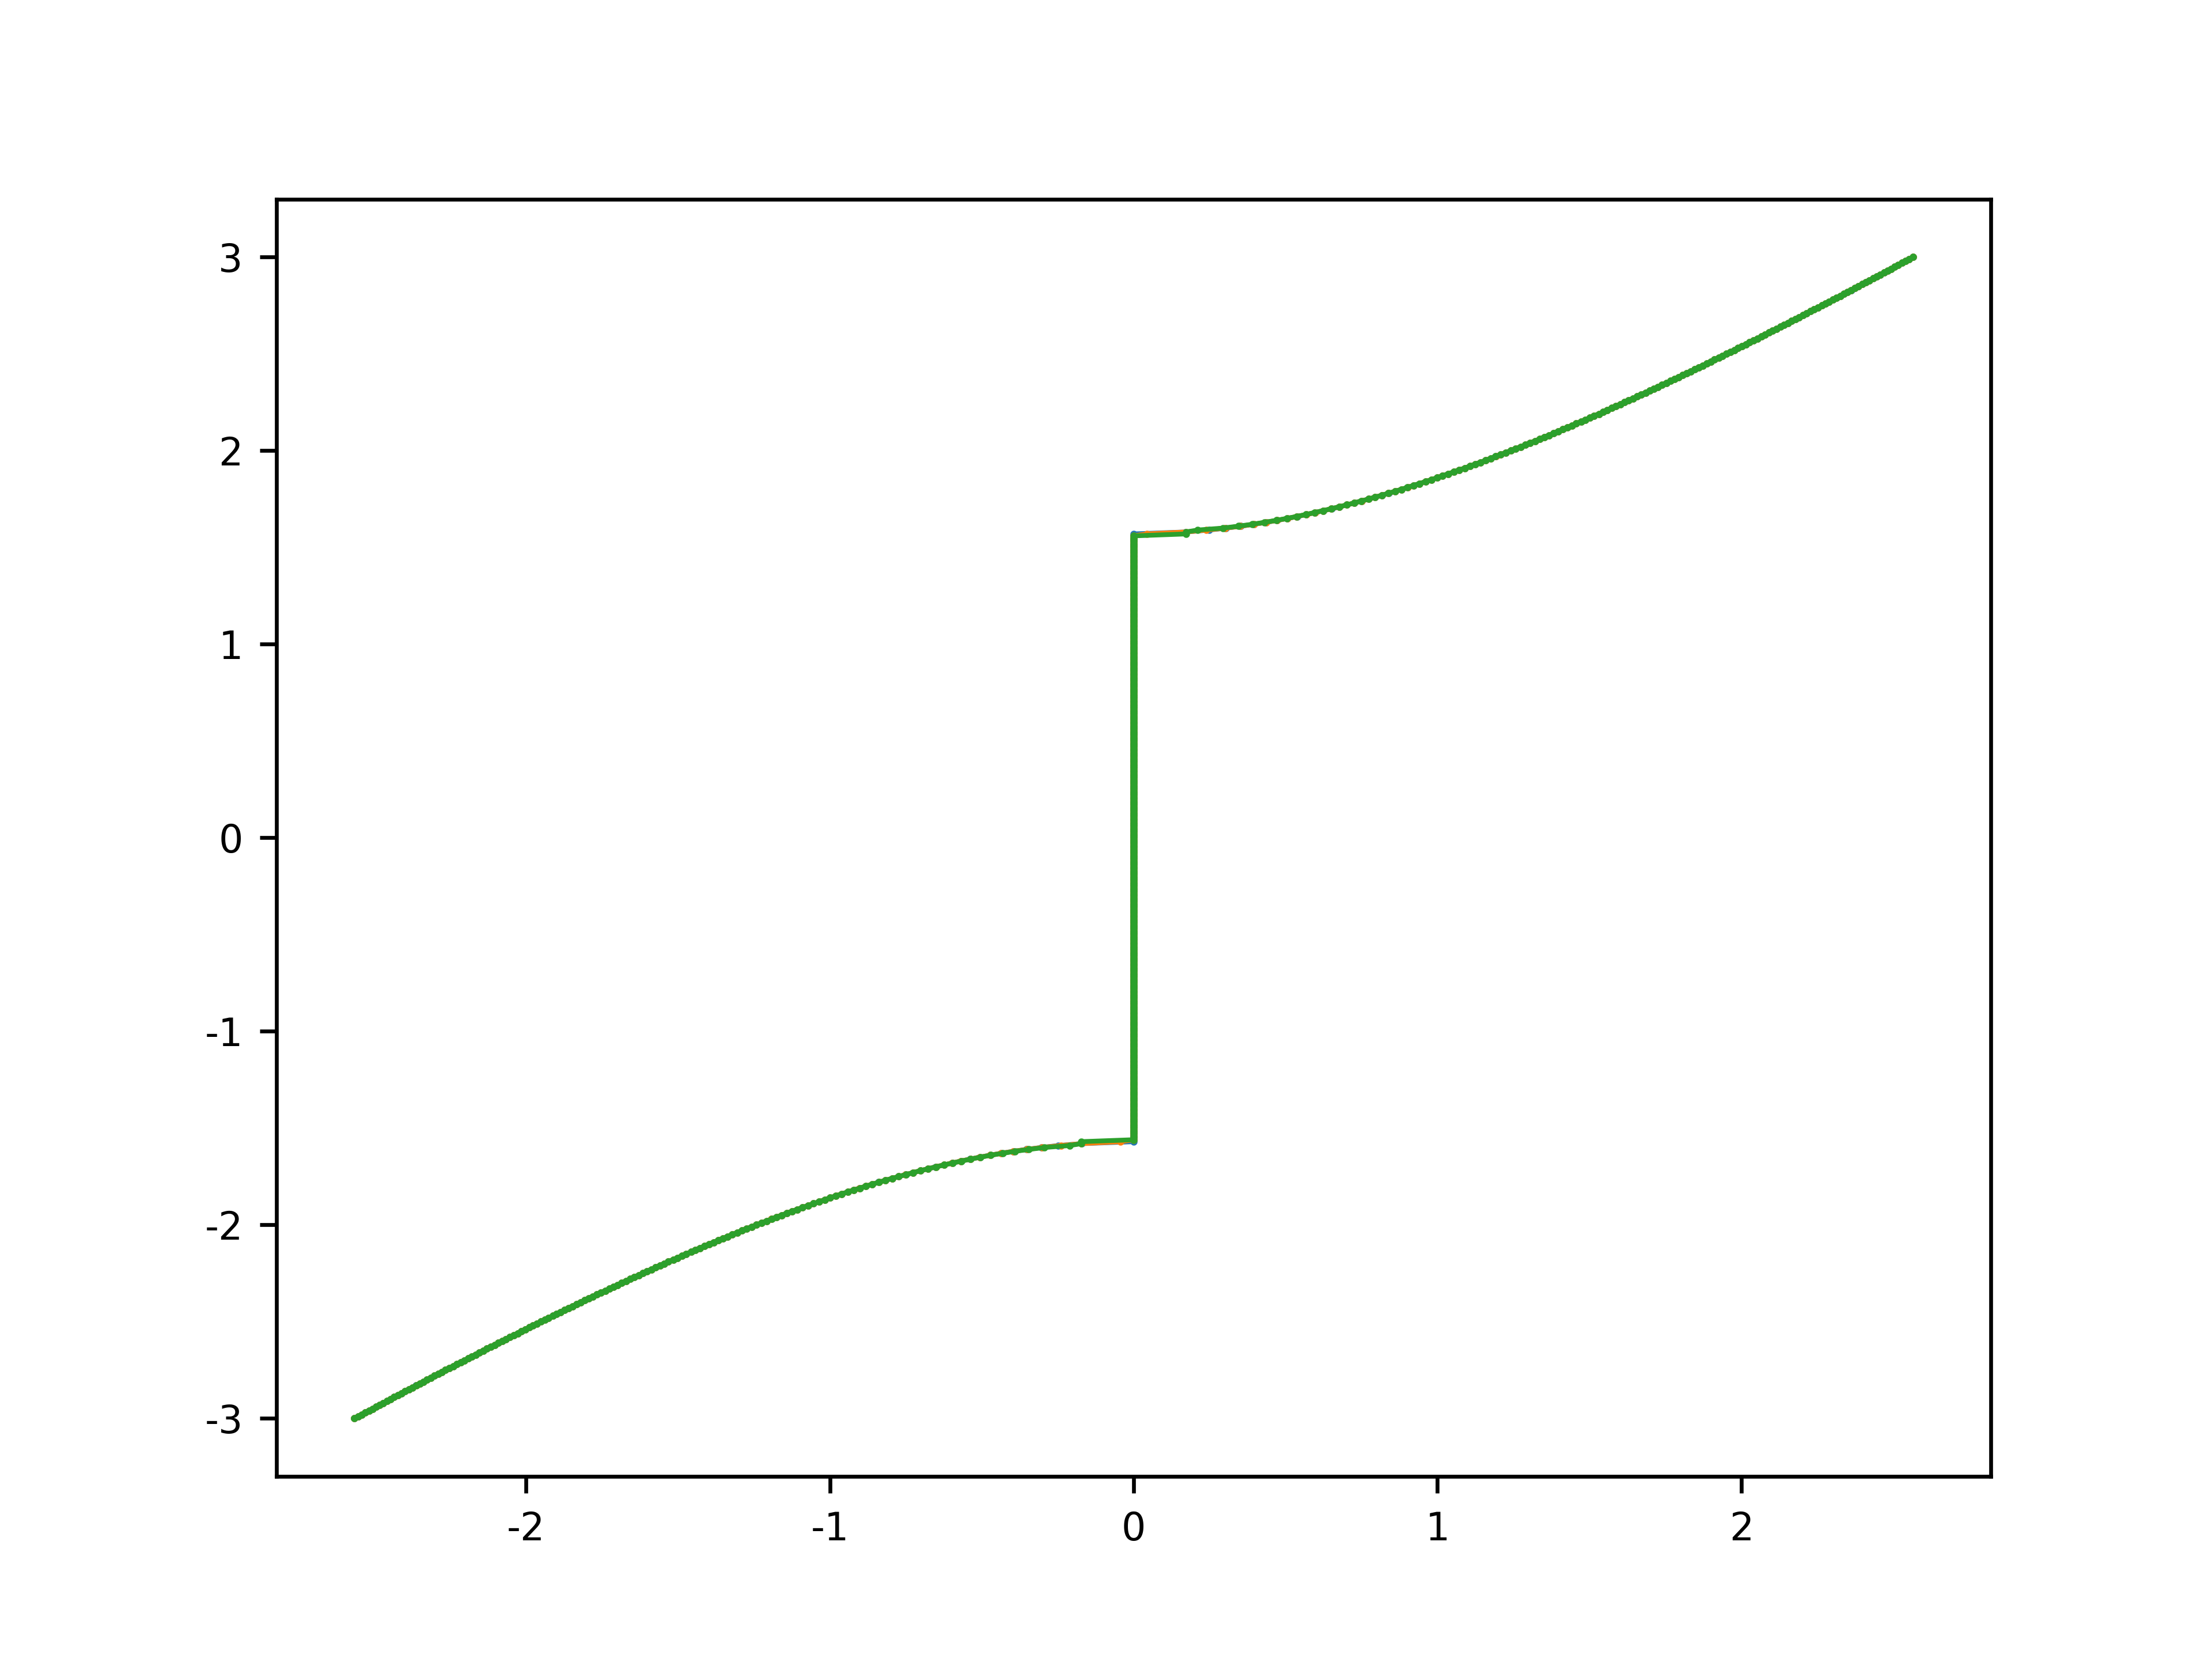

In [74]:
plt.plot(Vrsj[0, :], Ibias, ".-")
plt.plot(Vrsj[1, :], Ibias, ".-")
plt.plot(Vrsj[2, :], Ibias, ".-")

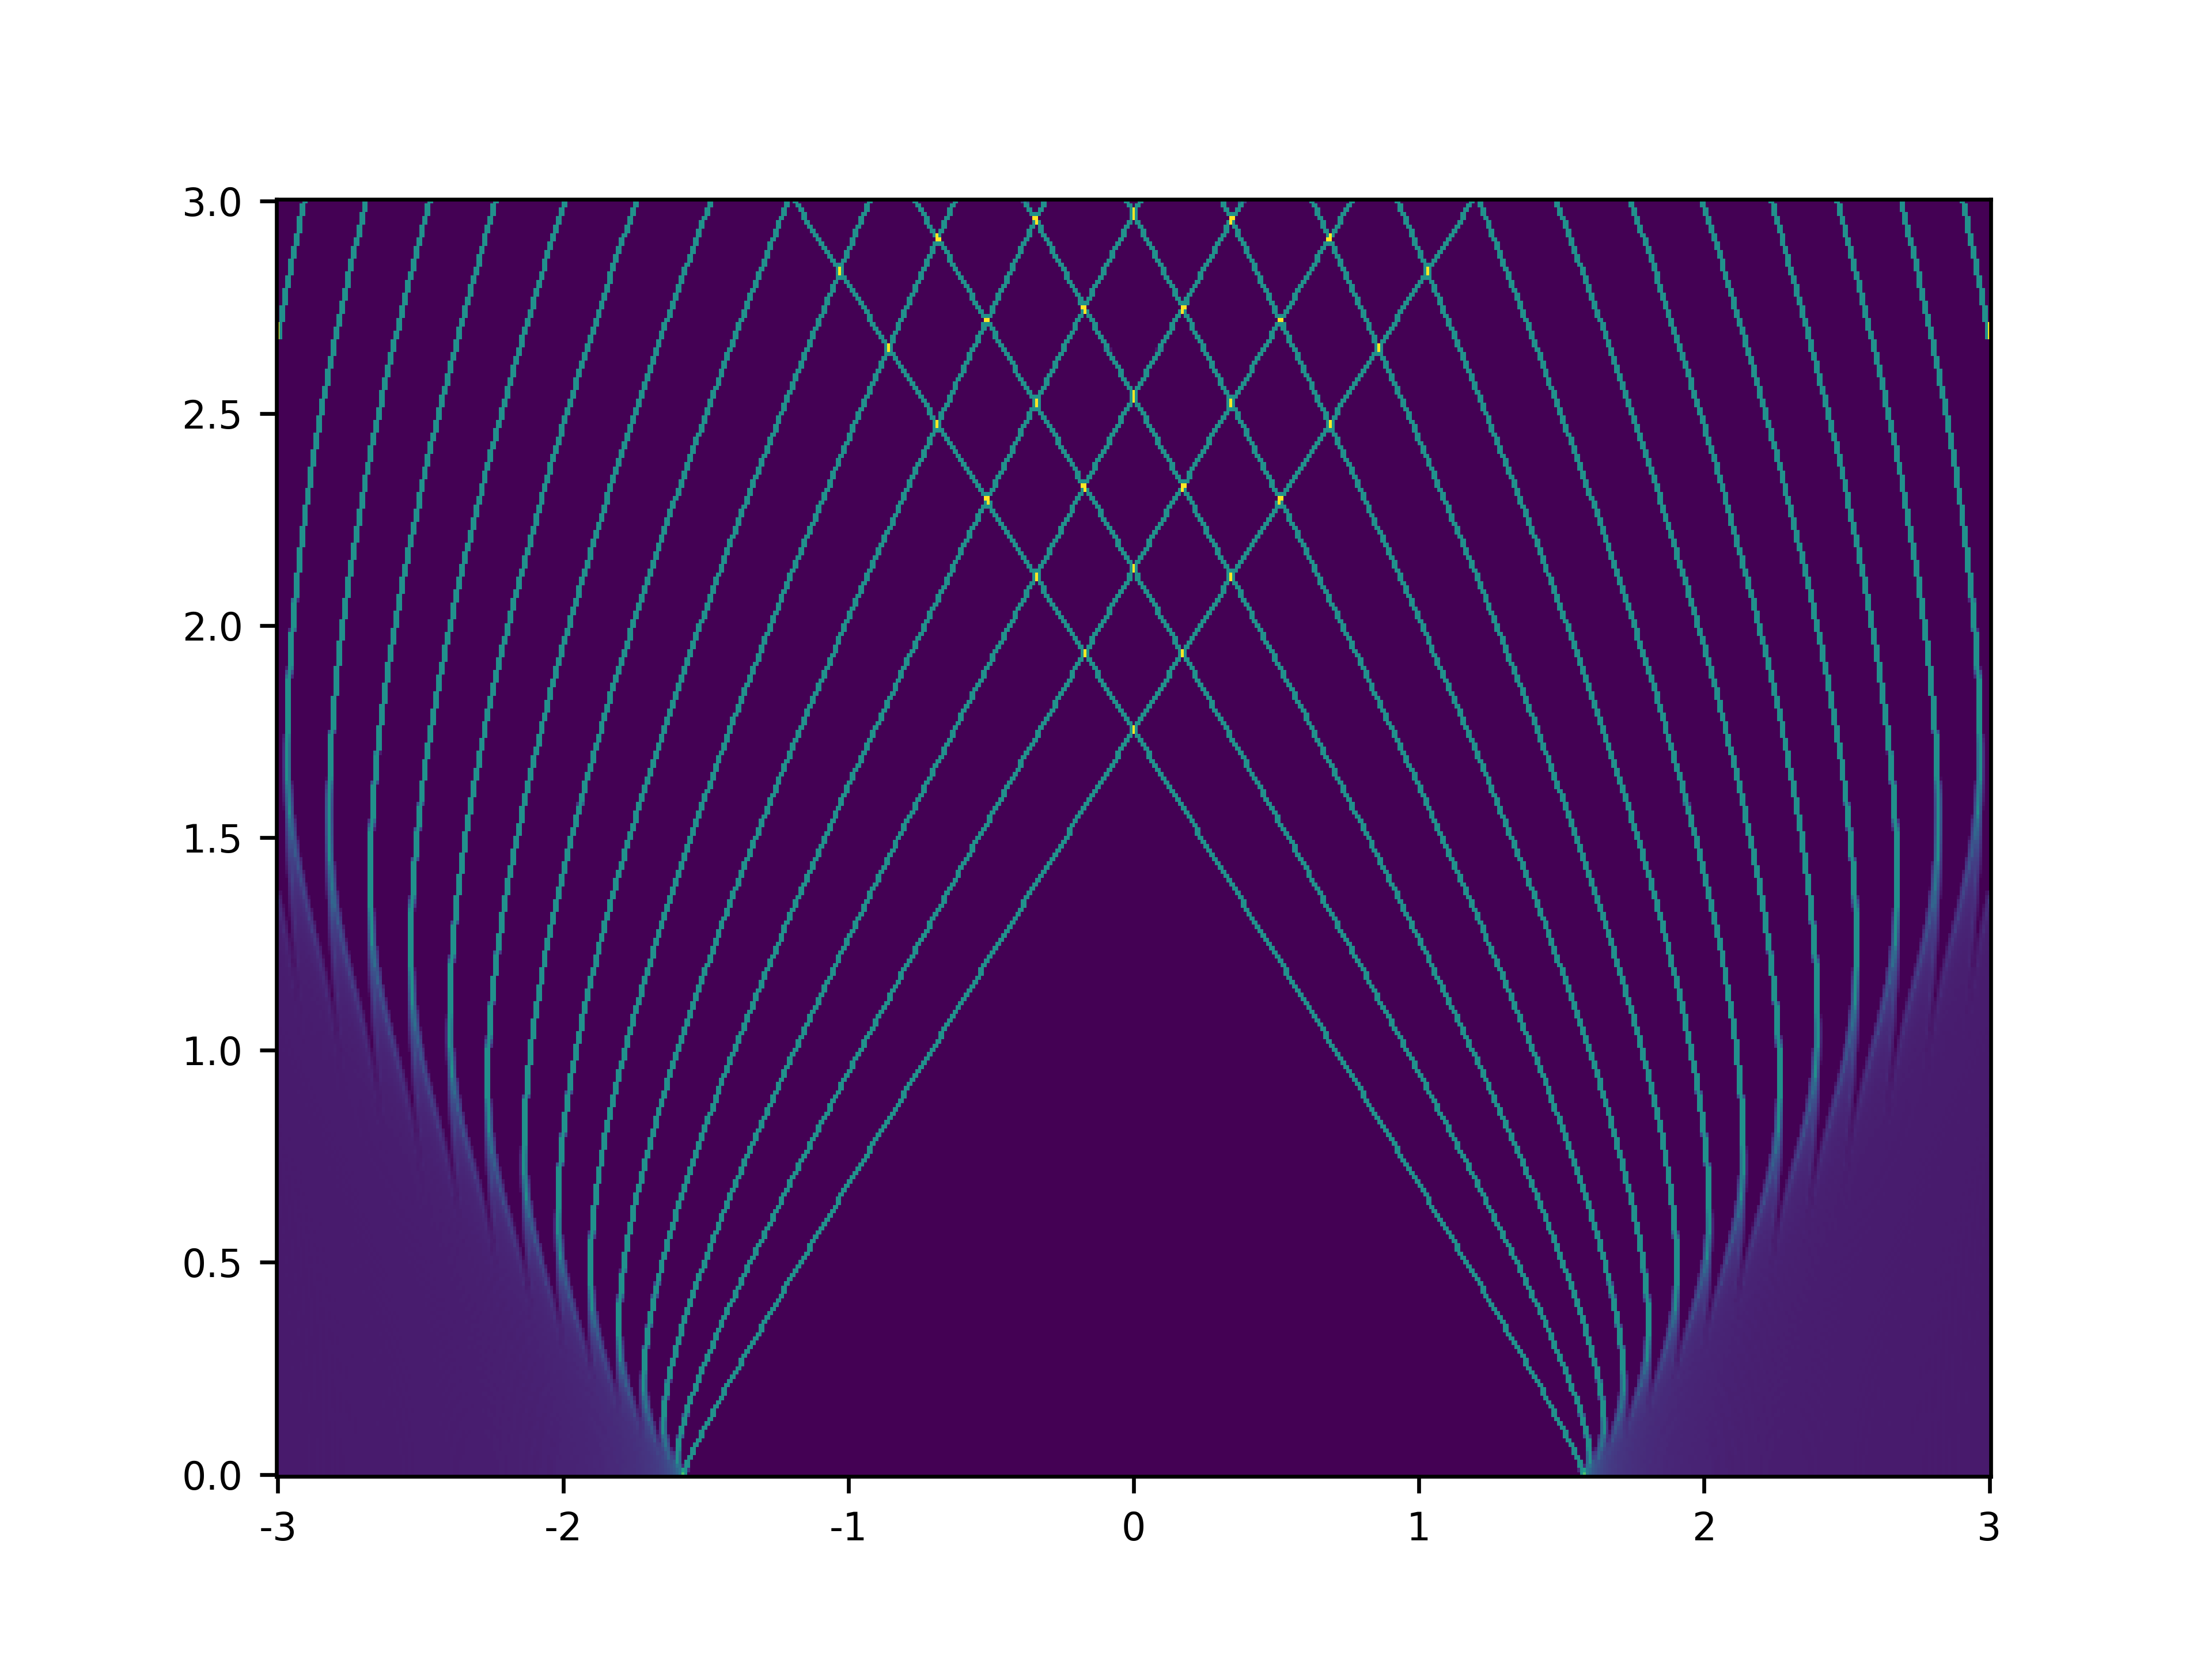

In [75]:
plt.pcolormesh(Ibias, Abias, np.gradient(Vrsj, Ibias, axis=-1))

In [23]:
# fig, ax = sc.get_figure(figsize=(1.9, 1.0))

# for i, a_mV in enumerate(A_mV):
#     v_over, i_over = sc.upsample(I_bias, V_over[:, i] * Delta_meV, factor=1000)
#     I_over = sc.bin_y_over_x(i_over, v_over, V_mV)
#     didv_over = np.gradient(I_over, V_mV) * Delta_meV
#     ax.plot(
#         V_mV / Delta_meV,
#         didv_over,
#         ".-",
#         color=sc.seeblau[2 * i],
#         ms=1,
#     )

# # ax.set_xlim(-2.6, 2.6)
# ax.set_ylim(-0.3, 3.3)

# xlabel = "$eV\\,/\\,\\Delta_0$"
# ylabel = "$\\mathrm{d}I_\\mathrm{bias}/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
# title = None

# sc.theory_layout(fig, ax, title, xlabel, ylabel)

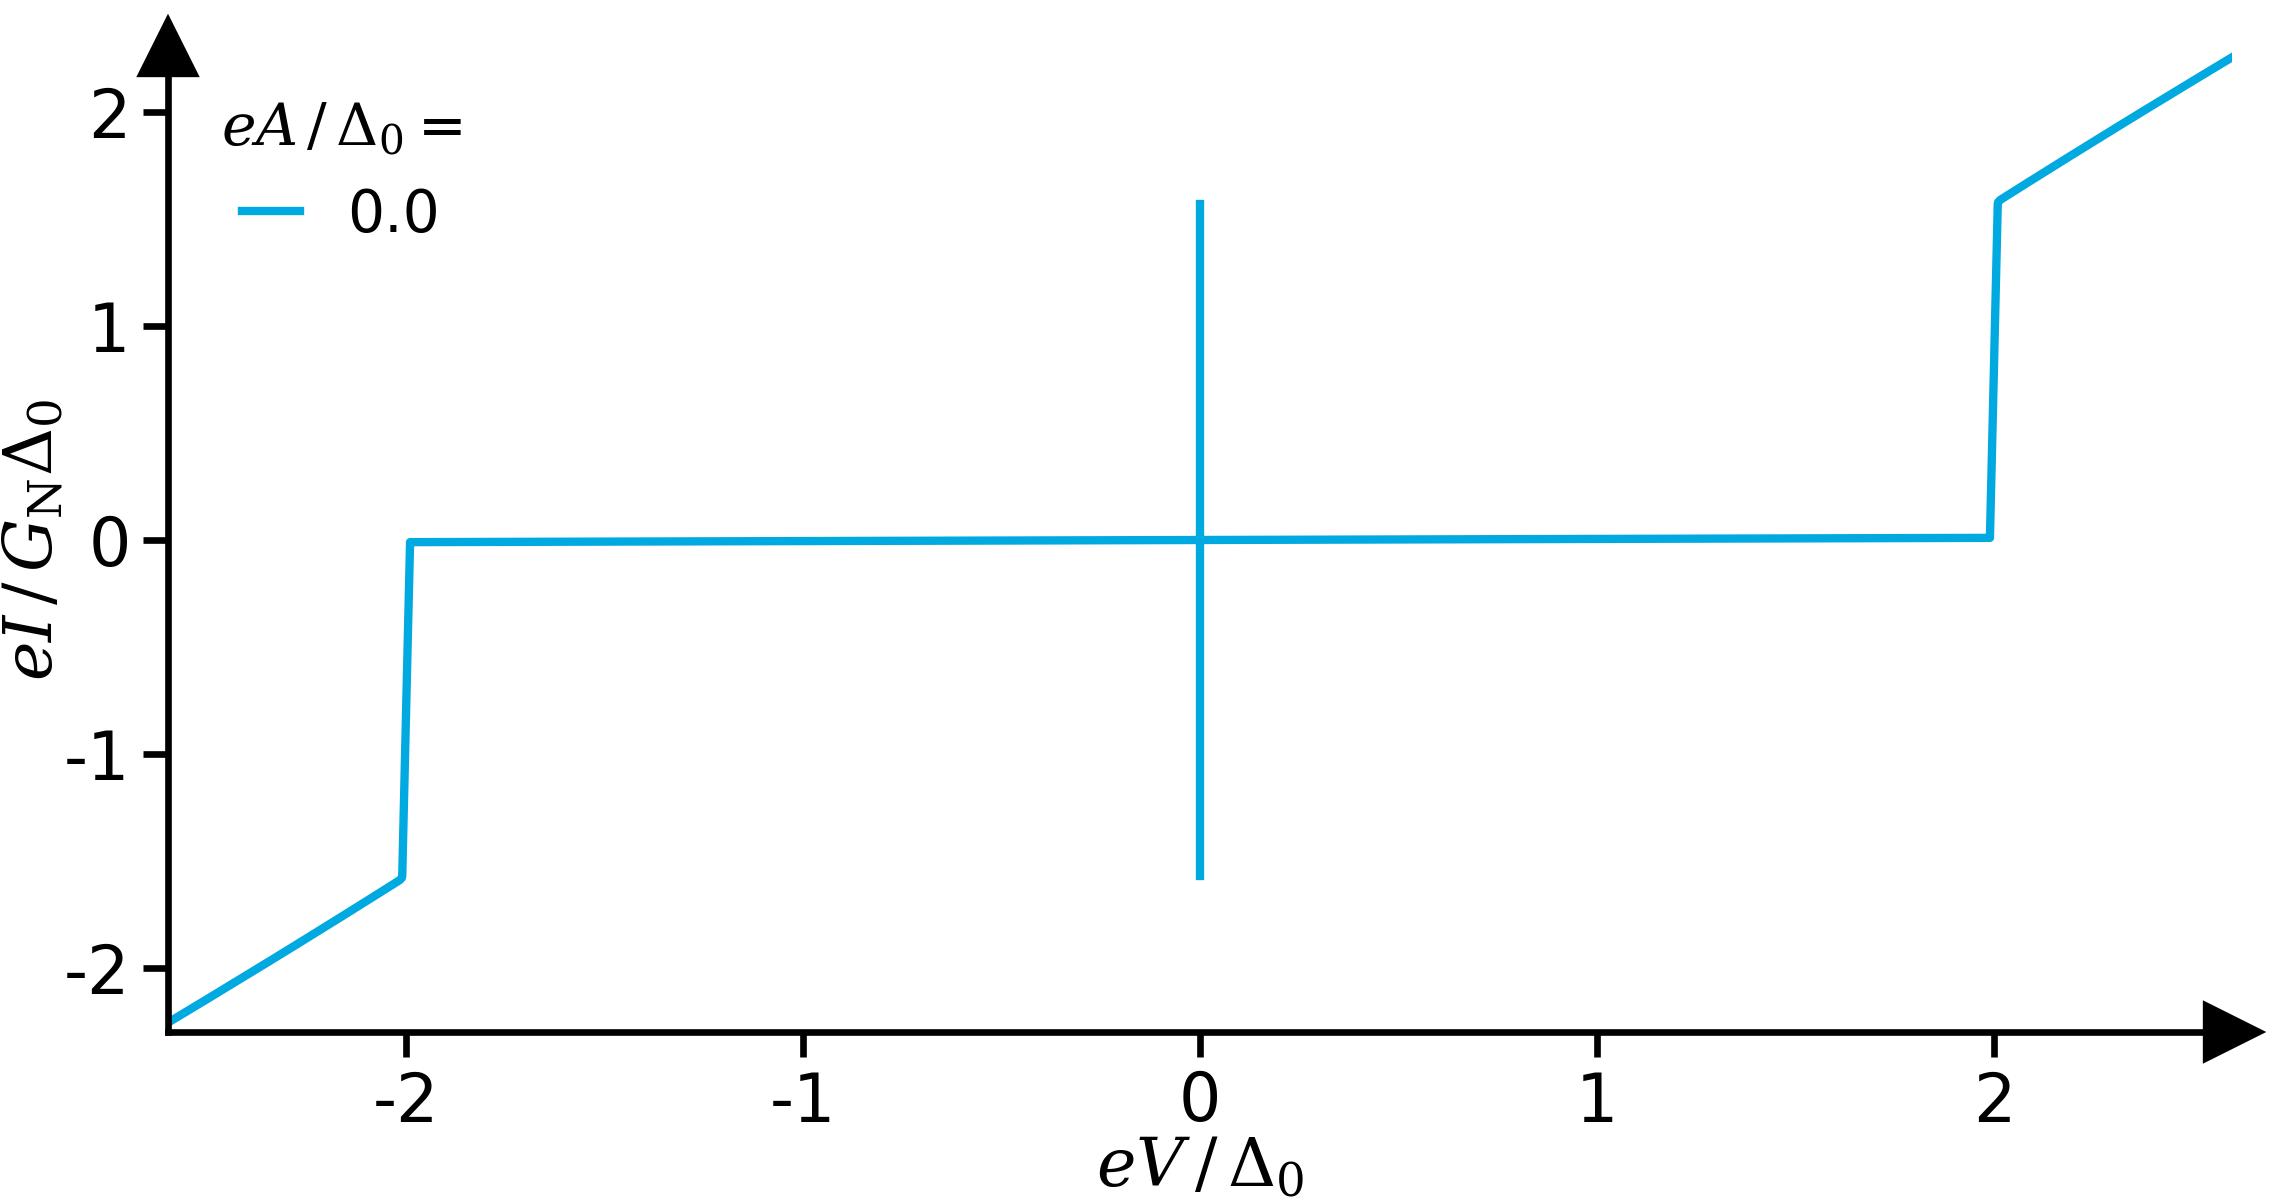

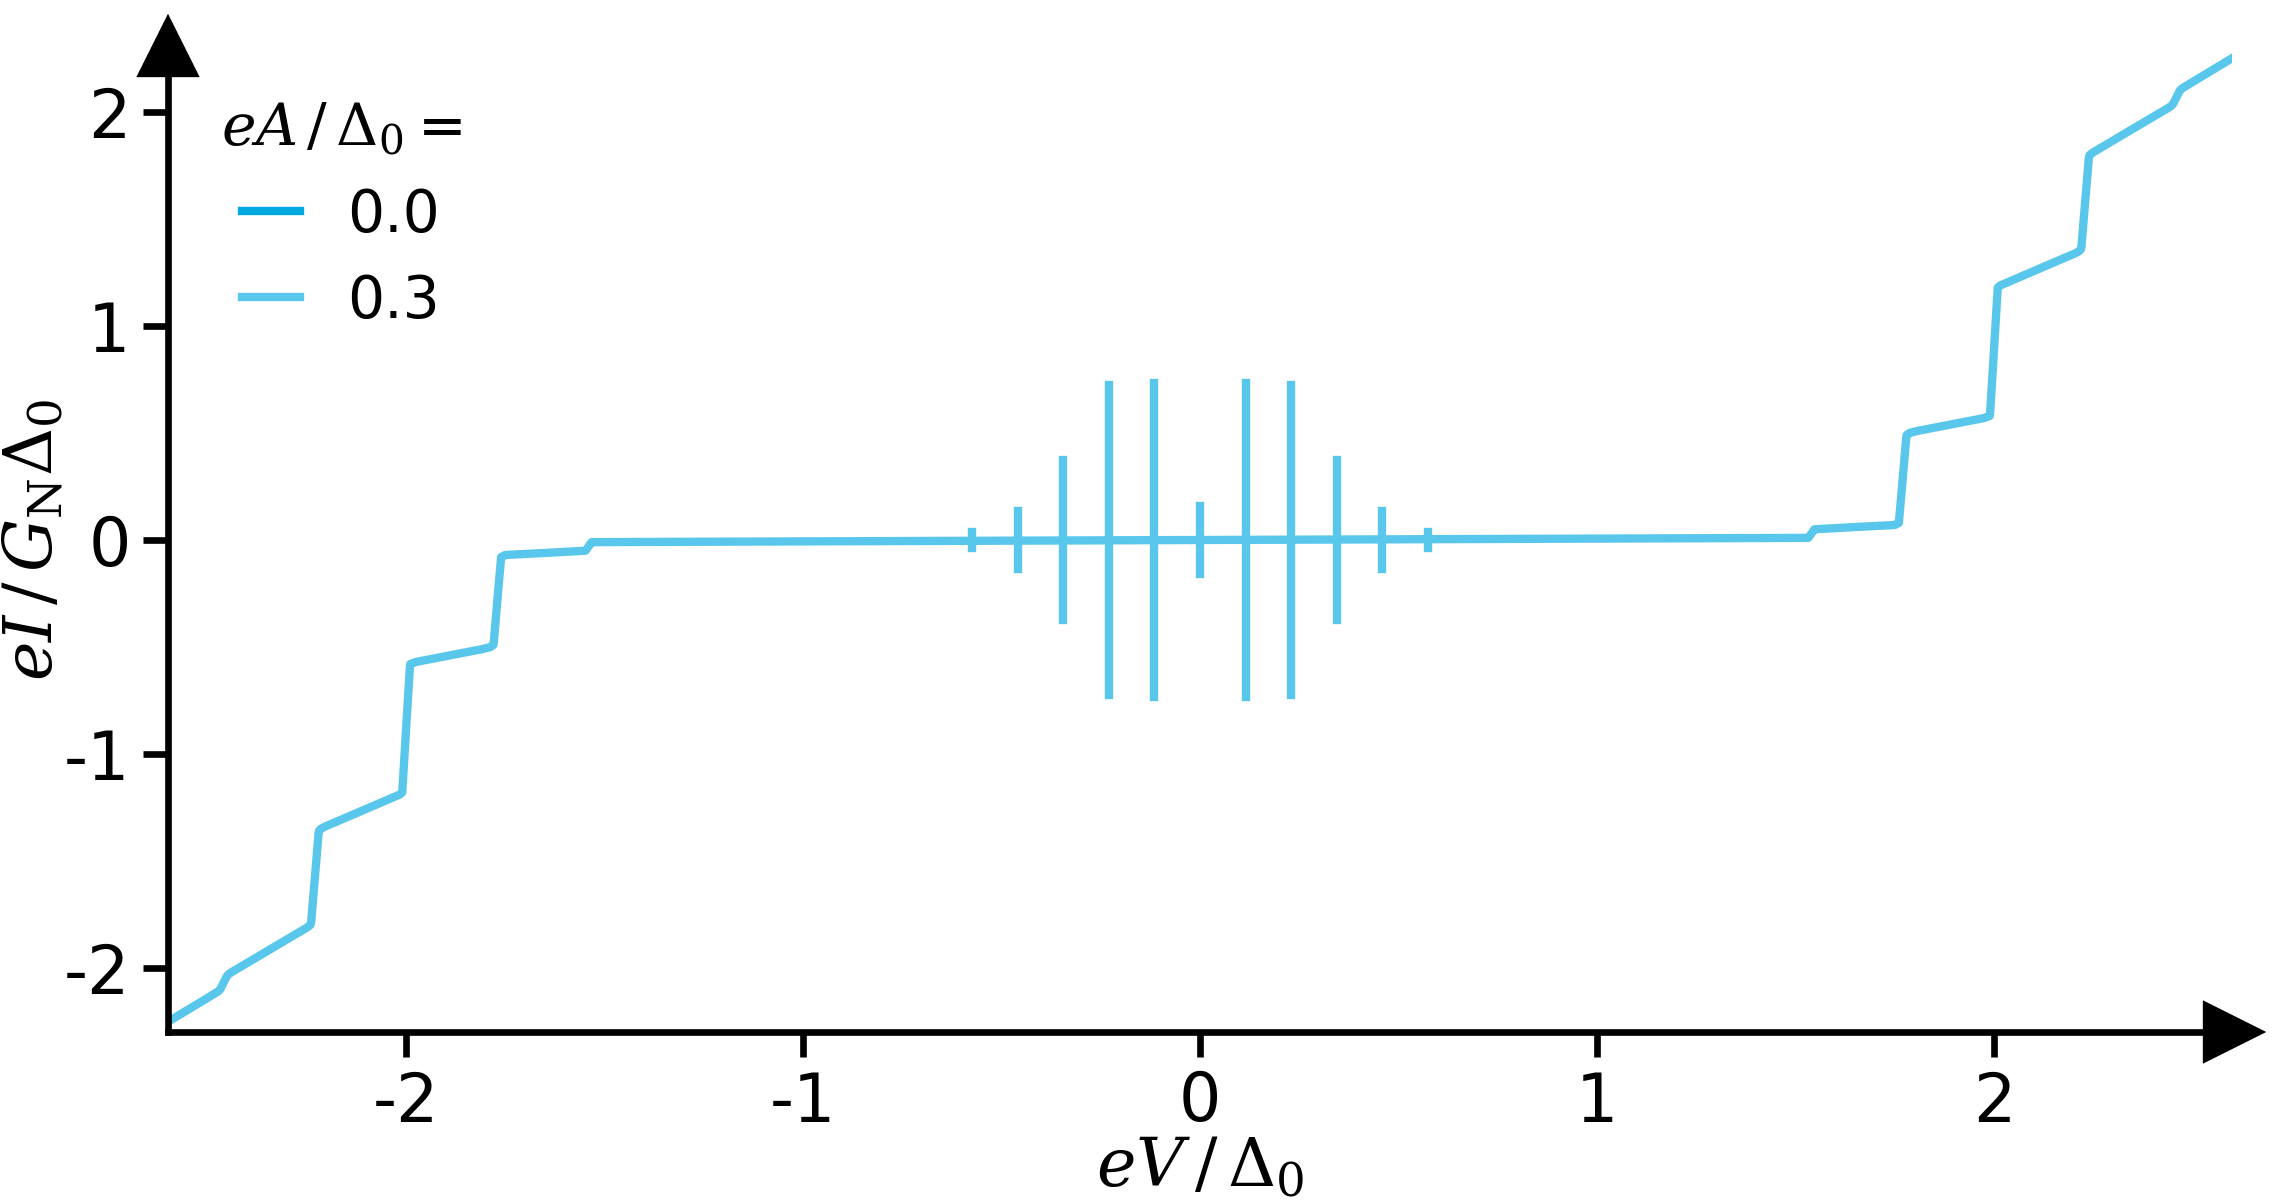

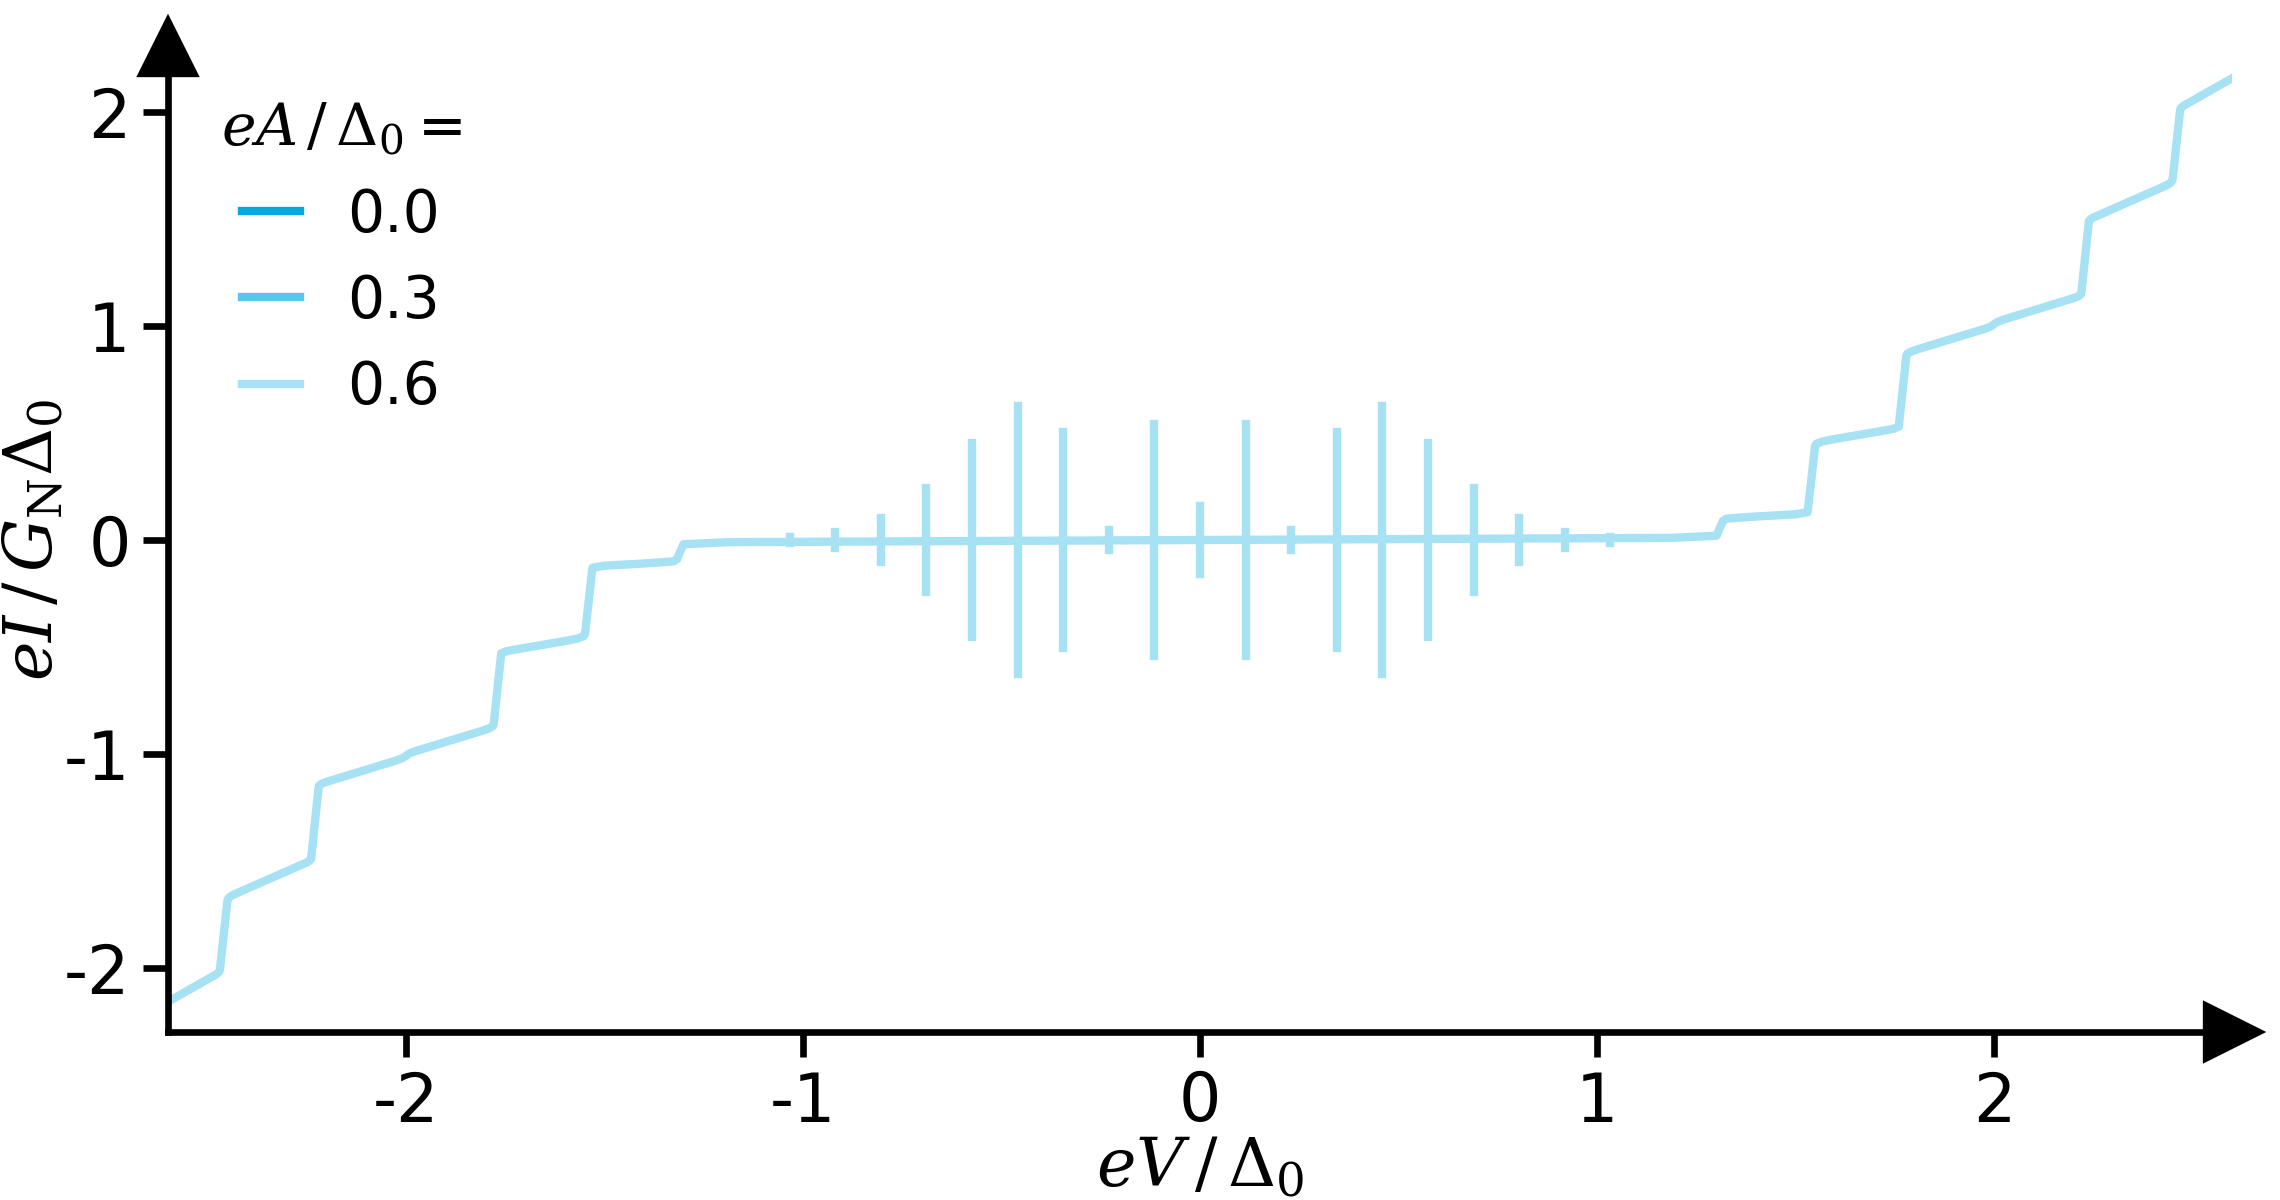

In [24]:
colors = [sc.seeblau100, sc.seeblau65, sc.seeblau35]

for i_a, a_mV in enumerate(A_mV):
    fig, ax = sc.get_figure(figsize=(3.8, 2.0), subfigure=False)
    ax.plot(
        V_PAT[:, i_a],
        I_bias,
        "-",
        color=colors[i_a],
        ms=1,
        zorder=i_a,
    )
    for i_n, n_i in enumerate(n):
        V_ss = V_n[i_n]
        I_ss = w[i_a, i_n] * I_C
        if I_ss >= 0.01:
            ax.plot(
                [V_ss, V_ss],
                [-I_ss, I_ss],
                "-",
                color=colors[i_a],
                zorder=3 - idx[i_a, i_n],
            )

    handles, labels = [], []
    for i, a_mV in enumerate(A_mV[: i_a + 1]):
        line_handle = Line2D([0], [0], color=colors[i], linestyle="-")
        label = f"{A_mV[i]/Delta_meV:1.1f}"
        handles.append(line_handle)
        labels.append(label)
    ax.legend(
        handles=handles,
        labels=labels,
        title="$eA\\,/\\,\\Delta_0 = $",
        handlelength=1.0,
        loc="upper left",
        frameon=False,
        fontsize=7,
        title_fontsize=7,
        ncols=1,
        columnspacing=1.0,
    )

    ax.set_xlim(-2.6, 2.6)
    ax.set_ylim(-2.3, 2.3)

    xlabel = "$eV\\,/\\,\\Delta_0$"
    ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
    title = f"theory/macro/shapiro-ideal-{i_a}"

    sc.theory_layout(fig, ax, title, xlabel, ylabel, padding=(0.3, 0.3))